In [1]:
# Forecast Model Research v2
# Cell 1: setup, guardrails, paths
#
# Goal:
# Build a new variance forecast methodology from scratch.
# This notebook is research-only. It must not overwrite production files.

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

# -----------------------------
# Project paths
# -----------------------------

PROJECT_ROOT = Path(r"C:\Users\patri\vrp_project")

DATA_DIR = PROJECT_ROOT / "data"
EXTERNAL_DIR = DATA_DIR / "external"
PROCESSED_DIR = DATA_DIR / "processed"
AUDIT_DIR = DATA_DIR / "audit"

# Research output folders for this v2 forecast work.
# These are intentionally separate from production files.
FORECAST_V2_DIR = PROCESSED_DIR / "forecast_model_research_v2"
FORECAST_V2_AUDIT_DIR = AUDIT_DIR / "forecast_model_research_v2"

FORECAST_V2_DIR.mkdir(parents=True, exist_ok=True)
FORECAST_V2_AUDIT_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Input files
# -----------------------------

SPX_DAILY_FILE = EXTERNAL_DIR / "spx_index_daily_fred_normalized.csv"

FEATURE_PANEL_FILE = PROCESSED_DIR / "production_feature_panel_v0_1.parquet"

IMPLIED_TERM_STRUCTURE_FILE = (
    PROCESSED_DIR
    / "vix_term_structure_history_v0_7_1_repaired_total_variance.parquet"
)

REALIZED_PANEL_FILE = PROCESSED_DIR / "realized_variance_panel_v0_1.parquet"
VRP_PANEL_FILE = PROCESSED_DIR / "vrp_panel_v0_1.parquet"

# -----------------------------
# Research constants
# -----------------------------

TARGET_TENORS = [9, 12, 15, 18, 21, 24, 27, 30, 33]

TRADING_DAYS_PER_YEAR = 252
CALENDAR_DAYS_PER_YEAR = 365

RESEARCH_VERSION = "forecast_model_research_v2"
RUN_TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")

# -----------------------------
# Guardrail: never write to production files from this notebook
# -----------------------------

PRODUCTION_FILES_DO_NOT_OVERWRITE = [
    FEATURE_PANEL_FILE,
    IMPLIED_TERM_STRUCTURE_FILE,
    REALIZED_PANEL_FILE,
    VRP_PANEL_FILE,
]

# Candidate outputs only
FORECAST_V2_DAILY_OUTPUT = (
    FORECAST_V2_DIR
    / f"forecast_v2_daily_variance_state_candidate_{RUN_TIMESTAMP}.parquet"
)

FORECAST_V2_TENOR_OUTPUT = (
    FORECAST_V2_DIR
    / f"forecast_v2_tenor_term_structure_candidate_{RUN_TIMESTAMP}.parquet"
)

FORECAST_V2_AUDIT_OUTPUT = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_setup_audit_{RUN_TIMESTAMP}.csv"
)

# -----------------------------
# File existence check
# -----------------------------

files_to_check = {
    "SPX daily normalized": SPX_DAILY_FILE,
    "Production feature panel": FEATURE_PANEL_FILE,
    "Implied term structure": IMPLIED_TERM_STRUCTURE_FILE,
    "Realized variance panel": REALIZED_PANEL_FILE,
    "VRP panel": VRP_PANEL_FILE,
}

audit_rows = []

for label, path in files_to_check.items():
    audit_rows.append({
        "label": label,
        "path": str(path),
        "exists": path.exists(),
        "size_mb": round(path.stat().st_size / 1_000_000, 2) if path.exists() else None,
    })

setup_audit_df = pd.DataFrame(audit_rows)
setup_audit_df.to_csv(FORECAST_V2_AUDIT_OUTPUT, index=False)

print("Forecast Model Research v2 setup complete.")
print()
print(f"Project root:        {PROJECT_ROOT}")
print(f"Research output dir: {FORECAST_V2_DIR}")
print(f"Audit output dir:    {FORECAST_V2_AUDIT_DIR}")
print(f"Run timestamp:       {RUN_TIMESTAMP}")
print()
print("Input file check:")
display(setup_audit_df)

missing = setup_audit_df.loc[~setup_audit_df["exists"], "label"].tolist()

if missing:
    raise FileNotFoundError(f"Missing required input files: {missing}")

print()
print("All required input files found.")
print("No production files will be overwritten by this notebook.")

Forecast Model Research v2 setup complete.

Project root:        C:\Users\patri\vrp_project
Research output dir: C:\Users\patri\vrp_project\data\processed\forecast_model_research_v2
Audit output dir:    C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2
Run timestamp:       20260703_202255

Input file check:


,label,path,exists,size_mb
0,SPX daily normalized,C:\Users\patri\vrp_project\data\external\spx_i...,True,0.13
1,Production feature panel,C:\Users\patri\vrp_project\data\processed\prod...,True,3.36
2,Implied term structure,C:\Users\patri\vrp_project\data\processed\vix_...,True,1.01
3,Realized variance panel,C:\Users\patri\vrp_project\data\processed\real...,True,0.83
4,VRP panel,C:\Users\patri\vrp_project\data\processed\vrp_...,True,2.44



All required input files found.
No production files will be overwritten by this notebook.


In [2]:
# Cell 2: load SPX returns and inspect current volatility inputs
#
# Purpose:
# 1. Load the SPX daily close / return history.
# 2. Confirm the return series is clean enough for forecast research.
# 3. Load the current production feature panel.
# 4. Diagnose the current forecast_vol vs trailing_realized_vol issue.
#
# This cell is diagnostic only. It does not change production files.

# -----------------------------
# Helper functions
# -----------------------------

def choose_col(df, candidates, required=True, label=None):
    """
    Pick the first matching column from a list of possible names.
    """
    cols_lower = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in cols_lower:
            return cols_lower[c.lower()]
    if required:
        raise KeyError(
            f"Could not find required column for {label or candidates}. "
            f"Available columns: {list(df.columns)}"
        )
    return None


def parse_project_date(s):
    """
    Parse either YYYYMMDD integers/strings or normal date strings.
    """
    s = s.copy()

    # Try YYYYMMDD first
    out = pd.to_datetime(s.astype(str), format="%Y%m%d", errors="coerce")

    # Fallback to normal parser
    missing = out.isna()
    if missing.any():
        out.loc[missing] = pd.to_datetime(s.loc[missing], errors="coerce")

    return out


def safe_numeric(s):
    return pd.to_numeric(s, errors="coerce")


# -----------------------------
# 1. Load SPX daily data
# -----------------------------

spx_raw = pd.read_csv(SPX_DAILY_FILE)

print("SPX daily file loaded.")
print(f"Shape: {spx_raw.shape}")
print("Columns:")
print(list(spx_raw.columns))

date_col = choose_col(
    spx_raw,
    ["date", "trade_date", "observation_date", "DATE"],
    label="SPX date",
)

close_col = choose_col(
    spx_raw,
    ["spx_close", "close", "SPX", "SP500", "value"],
    label="SPX close",
)

log_return_col = choose_col(
    spx_raw,
    ["spx_log_return", "log_return", "return", "log_ret"],
    required=False,
    label="SPX log return",
)

spx = spx_raw.copy()
spx["date"] = parse_project_date(spx[date_col])
spx["spx_close"] = safe_numeric(spx[close_col])

spx = spx.dropna(subset=["date", "spx_close"]).copy()
spx = spx.sort_values("date").drop_duplicates(subset=["date"], keep="last")

if log_return_col is not None:
    spx["spx_log_return"] = safe_numeric(spx_raw.loc[spx.index, log_return_col])
else:
    spx["spx_log_return"] = np.log(spx["spx_close"] / spx["spx_close"].shift(1))

# Recompute anyway for consistency check
spx["spx_log_return_recomputed"] = np.log(spx["spx_close"] / spx["spx_close"].shift(1))

if log_return_col is not None:
    spx["log_return_diff"] = (
        spx["spx_log_return"] - spx["spx_log_return_recomputed"]
    ).abs()
else:
    spx["spx_log_return"] = spx["spx_log_return_recomputed"]
    spx["log_return_diff"] = 0.0

# Research variance inputs
spx["daily_variance"] = spx["spx_log_return"] ** 2
spx["annualized_daily_variance"] = spx["daily_variance"] * TRADING_DAYS_PER_YEAR
spx["annualized_abs_return_vol_proxy"] = spx["spx_log_return"].abs() * np.sqrt(TRADING_DAYS_PER_YEAR) * 100

# Basic rolling realized vols for diagnostics only
for window in [5, 10, 21, 42, 63]:
    spx[f"rv_{window}d"] = (
        spx["spx_log_return"]
        .rolling(window)
        .std()
        * np.sqrt(TRADING_DAYS_PER_YEAR)
        * 100
    )

spx_summary = {
    "rows": len(spx),
    "first_date": spx["date"].min(),
    "last_date": spx["date"].max(),
    "missing_close_count": int(spx["spx_close"].isna().sum()),
    "missing_return_count": int(spx["spx_log_return"].isna().sum()),
    "max_abs_return": float(spx["spx_log_return"].abs().max()),
    "max_log_return_diff_if_existing": float(spx["log_return_diff"].max()),
}

print()
print("SPX clean summary:")
display(pd.DataFrame([spx_summary]))

print()
print("Latest SPX rows:")
display(
    spx[
        [
            "date",
            "spx_close",
            "spx_log_return",
            "daily_variance",
            "rv_5d",
            "rv_10d",
            "rv_21d",
            "rv_42d",
            "rv_63d",
        ]
    ].tail(10)
)

# -----------------------------
# 2. Load current production feature panel
# -----------------------------

feature = pd.read_parquet(FEATURE_PANEL_FILE)

print()
print("Production feature panel loaded.")
print(f"Shape: {feature.shape}")
print("Columns:")
print(list(feature.columns))

feature = feature.copy()
feature["date"] = parse_project_date(feature["trade_date"])
feature["tenor"] = safe_numeric(feature["tenor"]).astype("Int64")

# Make sure key fields are numeric
numeric_cols_to_check = [
    "spx_close",
    "vix_style_vol",
    "implied_variance",
    "trailing_realized_variance",
    "trailing_realized_vol",
    "forecast_variance",
    "forecast_vol",
    "vrp_log",
    "vrp_z_3m",
    "vrp_z_1y",
    "rv21d",
    "rsi14",
]

for col in numeric_cols_to_check:
    if col in feature.columns:
        feature[col] = safe_numeric(feature[col])

feature_summary = {
    "rows": len(feature),
    "first_date": feature["date"].min(),
    "last_date": feature["date"].max(),
    "tenor_count": feature["tenor"].nunique(),
    "min_tenor": int(feature["tenor"].min()),
    "max_tenor": int(feature["tenor"].max()),
}

print()
print("Feature panel summary:")
display(pd.DataFrame([feature_summary]))

# -----------------------------
# 3. Diagnose forecast_vol vs trailing_realized_vol
# -----------------------------

required_compare_cols = [
    "trailing_realized_variance",
    "trailing_realized_vol",
    "forecast_variance",
    "forecast_vol",
]

missing_compare_cols = [c for c in required_compare_cols if c not in feature.columns]

if missing_compare_cols:
    print()
    print("Cannot compare current forecast vs trailing realized.")
    print(f"Missing columns: {missing_compare_cols}")

else:
    feature["forecast_minus_trailing_realized_vol"] = (
        feature["forecast_vol"] - feature["trailing_realized_vol"]
    )

    feature["forecast_minus_trailing_realized_variance"] = (
        feature["forecast_variance"] - feature["trailing_realized_variance"]
    )

    compare_by_tenor = (
        feature
        .groupby("tenor")
        .agg(
            rows=("trade_date", "size"),
            mean_forecast_vol=("forecast_vol", "mean"),
            mean_trailing_realized_vol=("trailing_realized_vol", "mean"),
            mean_abs_vol_diff=("forecast_minus_trailing_realized_vol", lambda x: x.abs().mean()),
            max_abs_vol_diff=("forecast_minus_trailing_realized_vol", lambda x: x.abs().max()),
            mean_abs_variance_diff=("forecast_minus_trailing_realized_variance", lambda x: x.abs().mean()),
            max_abs_variance_diff=("forecast_minus_trailing_realized_variance", lambda x: x.abs().max()),
        )
        .reset_index()
    )

    print()
    print("Forecast vs trailing realized comparison by tenor:")
    display(compare_by_tenor)

    exact_same_vol_rows = np.isclose(
        feature["forecast_vol"],
        feature["trailing_realized_vol"],
        equal_nan=True,
    ).sum()

    exact_same_variance_rows = np.isclose(
        feature["forecast_variance"],
        feature["trailing_realized_variance"],
        equal_nan=True,
    ).sum()

    comparison_summary = {
        "total_rows": len(feature),
        "forecast_vol_equals_trailing_realized_vol_rows": int(exact_same_vol_rows),
        "forecast_variance_equals_trailing_realized_variance_rows": int(exact_same_variance_rows),
        "pct_forecast_vol_equal_to_trailing_realized": exact_same_vol_rows / len(feature),
        "pct_forecast_variance_equal_to_trailing_realized": exact_same_variance_rows / len(feature),
        "max_abs_vol_diff": float(feature["forecast_minus_trailing_realized_vol"].abs().max()),
        "max_abs_variance_diff": float(feature["forecast_minus_trailing_realized_variance"].abs().max()),
    }

    print()
    print("Current production forecast diagnostic:")
    display(pd.DataFrame([comparison_summary]))

# -----------------------------
# 4. Latest date curve diagnostic
# -----------------------------

latest_feature_date = feature["date"].max()

latest_curve_cols = [
    "date",
    "tenor",
    "tenor_group",
    "spx_close",
    "vix_style_vol",
    "trailing_realized_vol",
    "forecast_vol",
    "implied_variance",
    "trailing_realized_variance",
    "forecast_variance",
    "vrp_log",
    "vrp_z_3m",
    "vrp_z_1y",
    "rv21d",
    "rsi14",
]

latest_curve_cols = [c for c in latest_curve_cols if c in feature.columns]

latest_curve = (
    feature
    .loc[feature["date"] == latest_feature_date, latest_curve_cols]
    .sort_values("tenor")
    .copy()
)

print()
print(f"Latest feature curve date: {latest_feature_date.date()}")
display(latest_curve)

# -----------------------------
# 5. Save Cell 2 diagnostic audit
# -----------------------------

cell2_audit_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell2_input_diagnostics_{RUN_TIMESTAMP}.csv"
)

diagnostic_rows = []

diagnostic_rows.append({
    "section": "spx",
    "metric": "rows",
    "value": len(spx),
})

diagnostic_rows.append({
    "section": "spx",
    "metric": "first_date",
    "value": spx["date"].min(),
})

diagnostic_rows.append({
    "section": "spx",
    "metric": "last_date",
    "value": spx["date"].max(),
})

diagnostic_rows.append({
    "section": "feature",
    "metric": "rows",
    "value": len(feature),
})

diagnostic_rows.append({
    "section": "feature",
    "metric": "first_date",
    "value": feature["date"].min(),
})

diagnostic_rows.append({
    "section": "feature",
    "metric": "last_date",
    "value": feature["date"].max(),
})

if not missing_compare_cols:
    diagnostic_rows.append({
        "section": "forecast_vs_realized",
        "metric": "pct_forecast_vol_equal_to_trailing_realized",
        "value": comparison_summary["pct_forecast_vol_equal_to_trailing_realized"],
    })

    diagnostic_rows.append({
        "section": "forecast_vs_realized",
        "metric": "pct_forecast_variance_equal_to_trailing_realized",
        "value": comparison_summary["pct_forecast_variance_equal_to_trailing_realized"],
    })

cell2_audit_df = pd.DataFrame(diagnostic_rows)
cell2_audit_df.to_csv(cell2_audit_output, index=False)

print()
print(f"Cell 2 diagnostic audit saved to: {cell2_audit_output}")
print()
print("Cell 2 complete.")
print("Next step will be Cell 3: define what an intuitive forecast variance term structure should look like.")

SPX daily file loaded.
Shape: (2513, 4)
Columns:
['trade_date', 'date', 'spx_close', 'spx_log_return']

SPX clean summary:


,rows,first_date,last_date,missing_close_count,missing_return_count,max_abs_return,max_log_return_diff_if_existing
0,2513,2016-07-05,2026-07-02,0,1,0.127652,9.985502e-17



Latest SPX rows:


,date,spx_close,spx_log_return,daily_variance,rv_5d,rv_10d,rv_21d,rv_42d,rv_63d
2503,2026-06-18,7500.58,0.010788,1.163770e-04,18.638224,22.955495,16.505139,13.924420,15.602526
2504,2026-06-22,7472.79,-0.003712,1.377841e-05,19.026765,18.141440,16.180730,13.849784,15.250089
2505,2026-06-23,7365.46,-0.014467,2.092917e-04,15.738490,19.708603,16.949431,14.185029,15.491576
2506,2026-06-24,7358.22,-0.000983,9.671736e-07,15.972617,19.678733,16.879483,14.139153,15.461239
2507,2026-06-25,7357.49,-0.000099,9.843358e-09,14.332479,17.569738,16.699148,14.027034,15.448720
2508,2026-06-26,7354.02,-0.000472,2.225381e-07,9.603403,15.091640,16.694841,14.028756,14.950874
2509,2026-06-29,7440.43,0.011682,1.364584e-04,14.703919,16.115969,17.121552,14.216443,14.571025
2510,2026-06-30,7499.36,0.007889,6.223696e-05,9.221517,14.158151,17.358772,14.311475,14.551367
2511,2026-07-01,7483.23,-0.002153,4.636126e-06,9.616965,13.919420,17.329018,14.152630,13.581891
2512,2026-07-02,7483.24,0.000001,1.785752e-12,9.594357,12.259835,17.315750,14.144904,13.550600



Production feature panel loaded.
Shape: (18144, 57)
Columns:
['date', 'trade_date', 'tenor', 'target_days', 'tenor_group', 'spx_close', 'spx_log_return', 'implied_variance', 'vix_style_vol', 'trailing_realized_variance', 'trailing_realized_vol', 'forecast_variance', 'forecast_vol', 'primary_vrp_signal', 'vrp_log', 'vrp_z_3m', 'vrp_z_1y', 'rv21d', 'rsi14', 'forward_realized_variance', 'forward_realized_vol', 'rate_symbol', 'rate_pct', 'near_root', 'near_expiration', 'near_days', 'near_variance', 'next_root', 'next_expiration', 'next_days', 'next_variance', 'methodology_version', 'expiration_universe', 'trading_calendar_source', 'rate_source', 'option_source', 'quote_time', 'calc_time_ms', 'market_close_time', 'quote_time_used', 'quote_time_offset_minutes', 'raw_implied_variance', 'raw_vix_style_vol', 'is_repaired', 'repair_method', 'source_methodology_version', 'trailing_start_date', 'trailing_end_date', 'trailing_num_returns', 'trailing_window_complete', 'forward_start_date', 'forward

...


Current production forecast diagnostic:


,total_rows,forecast_vol_equals_trailing_realized_vol_rows,forecast_variance_equals_trailing_realized_variance_rows,pct_forecast_vol_equal_to_trailing_realized,pct_forecast_variance_equal_to_trailing_realized,max_abs_vol_diff,max_abs_variance_diff
0,18144,18144,18144,1.0,1.0,0.0,0.0



Latest feature curve date: 2026-07-02


,date,tenor,tenor_group,spx_close,vix_style_vol,trailing_realized_vol,forecast_vol,implied_variance,trailing_realized_variance,forecast_variance,vrp_log,vrp_z_3m,vrp_z_1y,rv21d,rsi14
18135,2026-07-02,9,front,7483.24,12.407236,9.107617,9.107617,0.015394,0.008295,0.008295,0.618337,0.403275,-0.194041,17.31575,54.73742
18136,2026-07-02,12,front,7483.24,13.207140,11.404474,11.404474,0.017443,0.013006,0.013006,0.293504,-0.326305,-0.837839,17.31575,54.73742
18137,2026-07-02,15,front,7483.24,13.702008,11.505130,11.505130,0.018775,0.013237,0.013237,0.349499,-0.072241,-0.758315,17.31575,54.73742
18138,2026-07-02,18,middle,7483.24,14.325276,14.201549,14.201549,0.020521,0.020168,0.020168,0.017349,-0.843503,-1.444087,17.31575,54.73742
18139,2026-07-02,21,middle,7483.24,14.754357,13.313140,13.313140,0.021769,0.017724,0.017724,0.205574,-0.469798,-1.157113,17.31575,54.73742
18140,2026-07-02,24,middle,7483.24,15.286667,15.573535,15.573535,0.023368,0.024253,0.024253,-0.037184,-1.095884,-1.688058,17.31575,54.73742
18141,2026-07-02,27,back,7483.24,15.781880,14.723522,14.723522,0.024907,0.021678,0.021678,0.138832,-0.769054,-1.456016,17.31575,54.73742
18142,2026-07-02,30,back,7483.24,16.117678,17.063190,17.063190,0.025978,0.029115,0.029115,-0.114014,-1.517228,-2.089902,17.31575,54.73742
18143,2026-07-02,33,back,7483.24,16.298491,16.298123,16.298123,0.026564,0.026563,0.026563,0.000045,-1.336469,-1.966260,17.31575,54.73742



Cell 2 diagnostic audit saved to: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell2_input_diagnostics_20260703_202255.csv

Cell 2 complete.
Next step will be Cell 3: define what an intuitive forecast variance term structure should look like.


In [3]:
# Cell 3: define forecast v2 objective and diagnose current forecast-curve choppiness
#
# Purpose:
# 1. Define what we want from a better variance forecast term structure.
# 2. Quantify why the current production forecast curve is not acceptable.
# 3. Set the research acceptance criteria before building candidate models.
#
# This cell is diagnostic only. It does not change production files.

# -----------------------------
# 1. Forecast v2 design principles
# -----------------------------

forecast_v2_design_principles = [
    {
        "principle": "Separate forecast from trailing realized window",
        "description": (
            "The production forecast should not simply equal each tenor's trailing realized volatility. "
            "Trailing realized vol is an input, not the final forecast curve."
        ),
    },
    {
        "principle": "Forecast variance, then convert to vol",
        "description": (
            "The model should be built in variance space because variance scales more naturally across horizons. "
            "Volatility is a display layer."
        ),
    },
    {
        "principle": "Use one current volatility state",
        "description": (
            "The curve should start from a common current variance state, rather than using separate noisy "
            "trailing windows for each tenor."
        ),
    },
    {
        "principle": "Mean-revert across horizon",
        "description": (
            "Short tenors should reflect the current volatility state more heavily. Longer tenors should move "
            "gradually toward a medium/long-run variance anchor."
        ),
    },
    {
        "principle": "Smooth term structure",
        "description": (
            "The forecast curve should not zig-zag across adjacent tenors unless there is a clear model reason. "
            "A smooth forecast curve is more intuitive and more robust for VRP measurement."
        ),
    },
    {
        "principle": "No look-ahead bias",
        "description": (
            "The forecast for date t must use only information available at or before date t."
        ),
    },
    {
        "principle": "Backtest impact matters",
        "description": (
            "A smoother curve is not enough. The replacement forecast must improve or at least preserve signal quality "
            "after thresholds are recalibrated."
        ),
    },
]

forecast_v2_design_df = pd.DataFrame(forecast_v2_design_principles)

print("Forecast v2 design principles:")
display(forecast_v2_design_df)


# -----------------------------
# 2. Candidate model families
# -----------------------------

forecast_v2_candidate_families = [
    {
        "candidate": "A. Constant-tenor baseline",
        "description": (
            "Use one current realized-volatility estimate across all tenors. Very smooth, but probably too flat."
        ),
        "status": "Diagnostic baseline only",
    },
    {
        "candidate": "B. EWMA mean-reverting variance curve",
        "description": (
            "Use short-run EWMA variance as current state and medium/long-run EWMA variance as anchor. "
            "Project each tenor with smooth mean reversion."
        ),
        "status": "First serious candidate",
    },
    {
        "candidate": "C. HAR-style variance forecast",
        "description": (
            "Blend daily, weekly, and monthly realized variance states. More flexible than EWMA but still interpretable."
        ),
        "status": "Second serious candidate",
    },
    {
        "candidate": "D. GARCH-style benchmark",
        "description": (
            "Use a formal volatility model as a benchmark. Useful later, but not the first step."
        ),
        "status": "Later benchmark",
    },
    {
        "candidate": "E. Intraday-enhanced forecast",
        "description": (
            "Use intraday SPX realized variance once intraday data is available. This is likely valuable later."
        ),
        "status": "Deferred until intraday data exists",
    },
]

forecast_v2_candidate_families_df = pd.DataFrame(forecast_v2_candidate_families)

print()
print("Forecast v2 candidate model families:")
display(forecast_v2_candidate_families_df)


# -----------------------------
# 3. Curve choppiness metric helpers
# -----------------------------

def curve_choppiness_metrics(curve_df, value_col, tenor_col="tenor"):
    """
    Quantify how jagged a curve is across tenor.

    Metrics:
    - avg_abs_adjacent_move: average absolute move between adjacent tenors, in vol points.
    - max_abs_adjacent_move: largest absolute move between adjacent tenors, in vol points.
    - slope_sign_changes: how often adjacent curve slopes flip direction.
    - avg_abs_second_diff: average absolute curvature/kink measure.
    - max_abs_second_diff: largest curvature/kink measure.

    These are diagnostics, not hard trading rules.
    """
    cols = [tenor_col, value_col]
    x = curve_df[cols].dropna().copy()
    x[tenor_col] = pd.to_numeric(x[tenor_col], errors="coerce")
    x[value_col] = pd.to_numeric(x[value_col], errors="coerce")
    x = x.dropna().sort_values(tenor_col)

    if len(x) < 3:
        return {
            "value_col": value_col,
            "points": len(x),
            "avg_abs_adjacent_move": np.nan,
            "max_abs_adjacent_move": np.nan,
            "slope_sign_changes": np.nan,
            "avg_abs_second_diff": np.nan,
            "max_abs_second_diff": np.nan,
        }

    y = x[value_col].to_numpy(dtype=float)

    adjacent_moves = np.diff(y)
    abs_adjacent_moves = np.abs(adjacent_moves)

    # Sign changes in slope. Ignore zero slopes.
    slope_sign = np.sign(adjacent_moves)
    slope_sign_nonzero = slope_sign[slope_sign != 0]

    if len(slope_sign_nonzero) <= 1:
        slope_sign_changes = 0
    else:
        slope_sign_changes = int(np.sum(slope_sign_nonzero[1:] != slope_sign_nonzero[:-1]))

    second_diff = np.diff(adjacent_moves)
    abs_second_diff = np.abs(second_diff)

    return {
        "value_col": value_col,
        "points": len(x),
        "avg_abs_adjacent_move": float(np.mean(abs_adjacent_moves)),
        "max_abs_adjacent_move": float(np.max(abs_adjacent_moves)),
        "slope_sign_changes": slope_sign_changes,
        "avg_abs_second_diff": float(np.mean(abs_second_diff)),
        "max_abs_second_diff": float(np.max(abs_second_diff)),
    }


def build_curve_choppiness_history(panel, value_cols, date_col="date", tenor_col="tenor"):
    rows = []

    for dt, g in panel.groupby(date_col):
        for value_col in value_cols:
            if value_col not in g.columns:
                continue

            metrics = curve_choppiness_metrics(
                g,
                value_col=value_col,
                tenor_col=tenor_col,
            )

            metrics["date"] = dt
            rows.append(metrics)

    out = pd.DataFrame(rows)

    if len(out) == 0:
        return out

    out["date"] = pd.to_datetime(out["date"])
    return out.sort_values(["date", "value_col"]).reset_index(drop=True)


# -----------------------------
# 4. Latest curve choppiness
# -----------------------------

latest_feature_date = feature["date"].max()

latest_curve_for_choppiness = (
    feature
    .loc[feature["date"] == latest_feature_date]
    .sort_values("tenor")
    .copy()
)

latest_choppiness_rows = []

for col in ["vix_style_vol", "forecast_vol", "trailing_realized_vol"]:
    if col in latest_curve_for_choppiness.columns:
        latest_choppiness_rows.append(
            curve_choppiness_metrics(
                latest_curve_for_choppiness,
                value_col=col,
                tenor_col="tenor",
            )
        )

latest_choppiness_df = pd.DataFrame(latest_choppiness_rows)
latest_choppiness_df.insert(0, "date", latest_feature_date)

print()
print(f"Latest curve choppiness diagnostics: {latest_feature_date.date()}")
display(latest_choppiness_df)


# -----------------------------
# 5. Historical choppiness distribution
# -----------------------------

curve_choppiness_history = build_curve_choppiness_history(
    feature,
    value_cols=[
        "vix_style_vol",
        "forecast_vol",
        "trailing_realized_vol",
    ],
    date_col="date",
    tenor_col="tenor",
)

one_year_start = latest_feature_date - pd.Timedelta(days=365)

curve_choppiness_last_year = (
    curve_choppiness_history
    .loc[curve_choppiness_history["date"] >= one_year_start]
    .copy()
)

choppiness_summary_all = (
    curve_choppiness_history
    .groupby("value_col")
    .agg(
        rows=("date", "size"),
        mean_avg_abs_adjacent_move=("avg_abs_adjacent_move", "mean"),
        median_avg_abs_adjacent_move=("avg_abs_adjacent_move", "median"),
        p95_avg_abs_adjacent_move=("avg_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_max_abs_adjacent_move=("max_abs_adjacent_move", "mean"),
        median_max_abs_adjacent_move=("max_abs_adjacent_move", "median"),
        p95_max_abs_adjacent_move=("max_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_slope_sign_changes=("slope_sign_changes", "mean"),
        median_slope_sign_changes=("slope_sign_changes", "median"),
        p95_slope_sign_changes=("slope_sign_changes", lambda x: x.quantile(0.95)),
        mean_max_abs_second_diff=("max_abs_second_diff", "mean"),
        median_max_abs_second_diff=("max_abs_second_diff", "median"),
        p95_max_abs_second_diff=("max_abs_second_diff", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

choppiness_summary_last_year = (
    curve_choppiness_last_year
    .groupby("value_col")
    .agg(
        rows=("date", "size"),
        mean_avg_abs_adjacent_move=("avg_abs_adjacent_move", "mean"),
        median_avg_abs_adjacent_move=("avg_abs_adjacent_move", "median"),
        p95_avg_abs_adjacent_move=("avg_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_max_abs_adjacent_move=("max_abs_adjacent_move", "mean"),
        median_max_abs_adjacent_move=("max_abs_adjacent_move", "median"),
        p95_max_abs_adjacent_move=("max_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_slope_sign_changes=("slope_sign_changes", "mean"),
        median_slope_sign_changes=("slope_sign_changes", "median"),
        p95_slope_sign_changes=("slope_sign_changes", lambda x: x.quantile(0.95)),
        mean_max_abs_second_diff=("max_abs_second_diff", "mean"),
        median_max_abs_second_diff=("max_abs_second_diff", "median"),
        p95_max_abs_second_diff=("max_abs_second_diff", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

print()
print("Historical curve choppiness summary: full sample")
display(choppiness_summary_all)

print()
print("Historical curve choppiness summary: latest 1 year")
display(choppiness_summary_last_year)


# -----------------------------
# 6. Current method problem statement
# -----------------------------

current_method_problem_statement = [
    {
        "problem": "Forecast equals trailing realized",
        "evidence": (
            "Cell 2 showed forecast_vol and trailing_realized_vol are identical for 100% of production feature rows."
        ),
        "why_it_matters": (
            "A forecast should be a model-generated expected future variance estimate, not just the same backward-looking window."
        ),
    },
    {
        "problem": "Tenor-specific trailing windows create jagged curves",
        "evidence": (
            "Each tenor uses a different calendar-day realized window, so adjacent tenors can jump around."
        ),
        "why_it_matters": (
            "The denominator becomes visually and statistically unstable across nearby tenors, which can distort VRP ranking."
        ),
    },
    {
        "problem": "VRP can be distorted by denominator noise",
        "evidence": (
            "If 24D trailing realized vol is high but 27D trailing realized vol is lower, the VRP curve can move for reasons "
            "unrelated to option-market richness."
        ),
        "why_it_matters": (
            "We want VRP to identify implied-vol richness, not artifacts from noisy trailing-window realized vol."
        ),
    },
    {
        "problem": "Dashboard confidence problem",
        "evidence": (
            "The forecast curve looks unintuitive and undermines confidence even when the data is technically correct."
        ),
        "why_it_matters": (
            "A production dashboard should make the data chain easier to trust, not harder."
        ),
    },
]

current_method_problem_statement_df = pd.DataFrame(current_method_problem_statement)

print()
print("Current method problem statement:")
display(current_method_problem_statement_df)


# -----------------------------
# 7. Forecast v2 acceptance criteria
# -----------------------------

forecast_v2_acceptance_criteria = [
    {
        "criterion": "Positive finite variance",
        "test": "forecast_variance_v2 must be positive and finite for all date x tenor rows after warmup.",
        "priority": "Required",
    },
    {
        "criterion": "Smooth across nearby tenors",
        "test": (
            "forecast_vol_v2 should have materially lower adjacent-tenor choppiness and second-difference kinks "
            "than current forecast_vol."
        ),
        "priority": "Required",
    },
    {
        "criterion": "Common state, tenor projection",
        "test": (
            "The curve should be generated from a common daily volatility state and a horizon projection, "
            "not separate trailing windows for each tenor."
        ),
        "priority": "Required",
    },
    {
        "criterion": "Responsive to recent volatility",
        "test": (
            "The short-tenor forecast should respond to recent market volatility and not be an over-smoothed flat line."
        ),
        "priority": "Required",
    },
    {
        "criterion": "Mean-reverting by horizon",
        "test": (
            "Longer tenors should gradually move toward a medium/long-run variance anchor."
        ),
        "priority": "Required",
    },
    {
        "criterion": "No look-ahead",
        "test": (
            "All v2 features for date t must be based only on SPX returns and inputs available through date t."
        ),
        "priority": "Required",
    },
    {
        "criterion": "Improves VRP denominator quality",
        "test": (
            "The resulting VRP curve should look more intuitive and should avoid large local distortions caused by denominator noise."
        ),
        "priority": "Required",
    },
    {
        "criterion": "Backtest validation",
        "test": (
            "After visual validation, thresholds must be recalibrated and signal results compared against the existing locked framework."
        ),
        "priority": "Required before promotion",
    },
]

forecast_v2_acceptance_criteria_df = pd.DataFrame(forecast_v2_acceptance_criteria)

print()
print("Forecast v2 acceptance criteria:")
display(forecast_v2_acceptance_criteria_df)


# -----------------------------
# 8. Save Cell 3 diagnostics
# -----------------------------

cell3_latest_choppiness_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell3_latest_choppiness_{RUN_TIMESTAMP}.csv"
)

cell3_choppiness_history_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell3_choppiness_history_{RUN_TIMESTAMP}.csv"
)

cell3_design_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell3_design_principles_{RUN_TIMESTAMP}.csv"
)

cell3_acceptance_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell3_acceptance_criteria_{RUN_TIMESTAMP}.csv"
)

latest_choppiness_df.to_csv(cell3_latest_choppiness_output, index=False)
curve_choppiness_history.to_csv(cell3_choppiness_history_output, index=False)
forecast_v2_design_df.to_csv(cell3_design_output, index=False)
forecast_v2_acceptance_criteria_df.to_csv(cell3_acceptance_output, index=False)

print()
print("Cell 3 outputs saved:")
print(f"Latest choppiness:    {cell3_latest_choppiness_output}")
print(f"Choppiness history:   {cell3_choppiness_history_output}")
print(f"Design principles:    {cell3_design_output}")
print(f"Acceptance criteria:  {cell3_acceptance_output}")

print()
print("Cell 3 complete.")
print("Next step will be Cell 4: build the first serious candidate — an EWMA mean-reverting variance forecast curve.")

Forecast v2 design principles:


,principle,description
0,Separate forecast from trailing realized window,The production forecast should not simply equa...
1,"Forecast variance, then convert to vol",The model should be built in variance space be...
2,Use one current volatility state,The curve should start from a common current v...
3,Mean-revert across horizon,Short tenors should reflect the current volati...
4,Smooth term structure,The forecast curve should not zig-zag across a...
5,No look-ahead bias,The forecast for date t must use only informat...
6,Backtest impact matters,A smoother curve is not enough. The replacemen...



Forecast v2 candidate model families:


,candidate,description,status
0,A. Constant-tenor baseline,Use one current realized-volatility estimate a...,Diagnostic baseline only
1,B. EWMA mean-reverting variance curve,Use short-run EWMA variance as current state a...,First serious candidate
2,C. HAR-style variance forecast,"Blend daily, weekly, and monthly realized vari...",Second serious candidate
3,D. GARCH-style benchmark,Use a formal volatility model as a benchmark. ...,Later benchmark
4,E. Intraday-enhanced forecast,Use intraday SPX realized variance once intrad...,Deferred until intraday data exists



Latest curve choppiness diagnostics: 2026-07-02


...


Current method problem statement:


,problem,evidence,why_it_matters
0,Forecast equals trailing realized,Cell 2 showed forecast_vol and trailing_realiz...,A forecast should be a model-generated expecte...
1,Tenor-specific trailing windows create jagged ...,Each tenor uses a different calendar-day reali...,The denominator becomes visually and statistic...
2,VRP can be distorted by denominator noise,If 24D trailing realized vol is high but 27D t...,"We want VRP to identify implied-vol richness, ..."
3,Dashboard confidence problem,The forecast curve looks unintuitive and under...,A production dashboard should make the data ch...



Forecast v2 acceptance criteria:


,criterion,test,priority
0,Positive finite variance,forecast_variance_v2 must be positive and fini...,Required
1,Smooth across nearby tenors,forecast_vol_v2 should have materially lower a...,Required
2,"Common state, tenor projection",The curve should be generated from a common da...,Required
3,Responsive to recent volatility,The short-tenor forecast should respond to rec...,Required
4,Mean-reverting by horizon,Longer tenors should gradually move toward a m...,Required
5,No look-ahead,All v2 features for date t must be based only ...,Required
6,Improves VRP denominator quality,The resulting VRP curve should look more intui...,Required
7,Backtest validation,"After visual validation, thresholds must be re...",Required before promotion



Cell 3 outputs saved:
Latest choppiness:    C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell3_latest_choppiness_20260703_202255.csv
Choppiness history:   C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell3_choppiness_history_20260703_202255.csv
Design principles:    C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell3_design_principles_20260703_202255.csv
Acceptance criteria:  C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell3_acceptance_criteria_20260703_202255.csv

Cell 3 complete.
Next step will be Cell 4: build the first serious candidate — an EWMA mean-reverting variance forecast curve.


In [4]:
# Cell 4: EWMA mean-reverting variance forecast candidate v2.A
#
# Purpose:
# Build the first serious replacement forecast curve.
#
# Current bad method:
#   each tenor forecast = that tenor's trailing realized variance window
#
# New candidate:
#   one daily current variance state
#   one daily long-run variance anchor
#   smooth mean-reverting projection across 9-33D tenors
#
# This cell is research-only. It does not change production files.

# -----------------------------
# 1. Model parameters
# -----------------------------

FORECAST_MODEL_ID = "forecast_v2_A_ewma_mean_reverting_variance"

# EWMA half-lives in trading days.
# These are intentionally simple starting values, not optimized.
SHORT_EWMA_HALFLIFE_DAYS = 10
MEDIUM_EWMA_HALFLIFE_DAYS = 21
LONG_EWMA_HALFLIFE_DAYS = 126

# Current variance state blend.
# Blend short and medium so the current state is responsive but not insane.
CURRENT_STATE_SHORT_WEIGHT = 0.70
CURRENT_STATE_MEDIUM_WEIGHT = 0.30

# Mean-reversion speed across forecast horizon.
# This controls how quickly the forecast horizon moves from current variance toward long-run variance.
# Larger = slower mean reversion / more current-state influence at longer tenors.
MEAN_REVERSION_HALFLIFE_CALENDAR_DAYS = 21

# EOD convention:
# For date t, use returns through date t. This is appropriate for after-close EOD research.
# Later, for intraday or pre-close use, we will shift this to avoid using unavailable same-day close.
USE_RETURN_THROUGH_SIGNAL_DATE = True

forecast_v2_params = {
    "forecast_model_id": FORECAST_MODEL_ID,
    "short_ewma_halflife_days": SHORT_EWMA_HALFLIFE_DAYS,
    "medium_ewma_halflife_days": MEDIUM_EWMA_HALFLIFE_DAYS,
    "long_ewma_halflife_days": LONG_EWMA_HALFLIFE_DAYS,
    "current_state_short_weight": CURRENT_STATE_SHORT_WEIGHT,
    "current_state_medium_weight": CURRENT_STATE_MEDIUM_WEIGHT,
    "mean_reversion_halflife_calendar_days": MEAN_REVERSION_HALFLIFE_CALENDAR_DAYS,
    "use_return_through_signal_date": USE_RETURN_THROUGH_SIGNAL_DATE,
}

forecast_v2_params_df = pd.DataFrame([forecast_v2_params])

print("Forecast v2.A parameters:")
display(forecast_v2_params_df)


# -----------------------------
# 2. Helper functions
# -----------------------------

def ewma_annualized_variance(return_series, halflife_days, annualization=TRADING_DAYS_PER_YEAR):
    """
    EWMA estimate of annualized variance from daily log returns.

    Input:
        daily log returns

    Output:
        annualized variance, not volatility
    """
    daily_var = return_series ** 2
    return daily_var.ewm(
        halflife=halflife_days,
        adjust=False,
        min_periods=halflife_days,
    ).mean() * annualization


def ou_average_variance_weight(tenor_days, mean_reversion_halflife_days):
    """
    Weight on current variance in the expected average variance over horizon T.

    If instantaneous variance mean-reverts:
        v_s = anchor + (current - anchor) * exp(-k s)

    Then average expected variance over 0..T is:
        anchor + (current - anchor) * (1 - exp(-kT)) / (kT)

    This is smoother and more appropriate than using exp(-kT) directly.
    """
    T = float(tenor_days)
    k = np.log(2) / float(mean_reversion_halflife_days)

    if T <= 0:
        return 1.0

    return (1 - np.exp(-k * T)) / (k * T)


def build_mean_reverting_variance_curve(
    current_variance,
    anchor_variance,
    target_tenors,
    mean_reversion_halflife_days,
):
    """
    Build smooth forecast variance curve across target tenors.
    """
    rows = []

    for tenor in target_tenors:
        weight_current = ou_average_variance_weight(
            tenor,
            mean_reversion_halflife_days,
        )

        forecast_variance = (
            anchor_variance
            + (current_variance - anchor_variance) * weight_current
        )

        rows.append({
            "tenor": int(tenor),
            "mr_weight_current": float(weight_current),
            "forecast_variance_v2_A": float(forecast_variance),
            "forecast_vol_v2_A": float(np.sqrt(forecast_variance) * 100)
                if pd.notna(forecast_variance) and forecast_variance > 0
                else np.nan,
        })

    return pd.DataFrame(rows)


# -----------------------------
# 3. Build daily variance states
# -----------------------------

spx_v2_state = spx.copy().sort_values("date").reset_index(drop=True)

# If we later want a before-close or next-day-safe version, shift the return input.
if USE_RETURN_THROUGH_SIGNAL_DATE:
    state_return = spx_v2_state["spx_log_return"]
else:
    state_return = spx_v2_state["spx_log_return"].shift(1)

spx_v2_state["ewma_var_short"] = ewma_annualized_variance(
    state_return,
    SHORT_EWMA_HALFLIFE_DAYS,
)

spx_v2_state["ewma_var_medium"] = ewma_annualized_variance(
    state_return,
    MEDIUM_EWMA_HALFLIFE_DAYS,
)

spx_v2_state["ewma_var_long_anchor"] = ewma_annualized_variance(
    state_return,
    LONG_EWMA_HALFLIFE_DAYS,
)

spx_v2_state["current_variance_state_v2_A"] = (
    CURRENT_STATE_SHORT_WEIGHT * spx_v2_state["ewma_var_short"]
    + CURRENT_STATE_MEDIUM_WEIGHT * spx_v2_state["ewma_var_medium"]
)

spx_v2_state["long_run_variance_anchor_v2_A"] = spx_v2_state["ewma_var_long_anchor"]

spx_v2_state["current_vol_state_v2_A"] = (
    np.sqrt(spx_v2_state["current_variance_state_v2_A"]) * 100
)

spx_v2_state["long_run_vol_anchor_v2_A"] = (
    np.sqrt(spx_v2_state["long_run_variance_anchor_v2_A"]) * 100
)

state_cols = [
    "date",
    "spx_close",
    "spx_log_return",
    "ewma_var_short",
    "ewma_var_medium",
    "ewma_var_long_anchor",
    "current_variance_state_v2_A",
    "long_run_variance_anchor_v2_A",
    "current_vol_state_v2_A",
    "long_run_vol_anchor_v2_A",
]

print()
print("Latest daily variance states:")
display(spx_v2_state[state_cols].tail(10))


# -----------------------------
# 4. Build date x tenor forecast curve
# -----------------------------

feature_dates = (
    feature[["date", "trade_date"]]
    .drop_duplicates()
    .sort_values("date")
    .copy()
)

daily_state_for_feature = feature_dates.merge(
    spx_v2_state[
        [
            "date",
            "current_variance_state_v2_A",
            "long_run_variance_anchor_v2_A",
            "current_vol_state_v2_A",
            "long_run_vol_anchor_v2_A",
        ]
    ],
    on="date",
    how="left",
    validate="one_to_one",
)

forecast_curve_rows = []

for _, row in daily_state_for_feature.iterrows():
    dt = row["date"]
    trade_date = row["trade_date"]
    current_var = row["current_variance_state_v2_A"]
    anchor_var = row["long_run_variance_anchor_v2_A"]

    if pd.isna(current_var) or pd.isna(anchor_var):
        continue

    curve = build_mean_reverting_variance_curve(
        current_variance=current_var,
        anchor_variance=anchor_var,
        target_tenors=TARGET_TENORS,
        mean_reversion_halflife_days=MEAN_REVERSION_HALFLIFE_CALENDAR_DAYS,
    )

    curve.insert(0, "date", dt)
    curve.insert(1, "trade_date", trade_date)
    curve["current_variance_state_v2_A"] = current_var
    curve["long_run_variance_anchor_v2_A"] = anchor_var
    curve["current_vol_state_v2_A"] = row["current_vol_state_v2_A"]
    curve["long_run_vol_anchor_v2_A"] = row["long_run_vol_anchor_v2_A"]
    curve["forecast_model_id"] = FORECAST_MODEL_ID

    forecast_curve_rows.append(curve)

forecast_v2_A_curve = pd.concat(forecast_curve_rows, ignore_index=True)

# Merge with current production feature panel so we can compare old vs new.
forecast_v2_A_compare = feature.merge(
    forecast_v2_A_curve,
    on=["date", "trade_date", "tenor"],
    how="left",
    validate="one_to_one",
)

forecast_v2_A_compare["forecast_vol_old"] = forecast_v2_A_compare["forecast_vol"]
forecast_v2_A_compare["forecast_variance_old"] = forecast_v2_A_compare["forecast_variance"]

forecast_v2_A_compare["vrp_log_v2_A"] = np.log(
    forecast_v2_A_compare["implied_variance"]
    / forecast_v2_A_compare["forecast_variance_v2_A"]
)

forecast_v2_A_compare["vrp_premium_pct_v2_A"] = (
    np.exp(forecast_v2_A_compare["vrp_log_v2_A"]) - 1
) * 100

print()
print("Forecast v2.A curve built.")
print(f"Rows: {len(forecast_v2_A_curve):,}")
print(f"Date range: {forecast_v2_A_curve['date'].min().date()} to {forecast_v2_A_curve['date'].max().date()}")


# -----------------------------
# 5. Latest curve comparison
# -----------------------------

latest_feature_date = feature["date"].max()

latest_v2_A_curve = (
    forecast_v2_A_compare
    .loc[forecast_v2_A_compare["date"] == latest_feature_date]
    .sort_values("tenor")
    .copy()
)

latest_v2_A_cols = [
    "date",
    "tenor",
    "tenor_group",
    "vix_style_vol",
    "forecast_vol_old",
    "trailing_realized_vol",
    "forecast_vol_v2_A",
    "current_vol_state_v2_A",
    "long_run_vol_anchor_v2_A",
    "mr_weight_current",
    "vrp_log",
    "vrp_log_v2_A",
    "vrp_premium_pct_v2_A",
]

print()
print(f"Latest curve comparison: {latest_feature_date.date()}")
display(latest_v2_A_curve[latest_v2_A_cols])


# -----------------------------
# 6. Choppiness comparison: old forecast vs v2.A forecast
# -----------------------------

chop_input = forecast_v2_A_compare.copy()

# Rename v2 field into common format for the helper
chop_input["forecast_vol_v2_A"] = safe_numeric(chop_input["forecast_vol_v2_A"])

latest_choppiness_v2_rows = []

for col in ["vix_style_vol", "forecast_vol_old", "forecast_vol_v2_A"]:
    latest_choppiness_v2_rows.append(
        curve_choppiness_metrics(
            latest_v2_A_curve.rename(columns={"forecast_vol_old": "forecast_vol_old"}),
            value_col=col,
            tenor_col="tenor",
        )
    )

latest_choppiness_v2_df = pd.DataFrame(latest_choppiness_v2_rows)
latest_choppiness_v2_df.insert(0, "date", latest_feature_date)

print()
print(f"Latest choppiness comparison: {latest_feature_date.date()}")
display(latest_choppiness_v2_df)

chop_history_v2 = build_curve_choppiness_history(
    chop_input,
    value_cols=[
        "vix_style_vol",
        "forecast_vol_old",
        "forecast_vol_v2_A",
    ],
    date_col="date",
    tenor_col="tenor",
)

one_year_start = latest_feature_date - pd.Timedelta(days=365)

chop_history_v2_last_year = (
    chop_history_v2
    .loc[chop_history_v2["date"] >= one_year_start]
    .copy()
)

chop_summary_v2_full = (
    chop_history_v2
    .groupby("value_col")
    .agg(
        rows=("date", "size"),
        mean_avg_abs_adjacent_move=("avg_abs_adjacent_move", "mean"),
        median_avg_abs_adjacent_move=("avg_abs_adjacent_move", "median"),
        p95_avg_abs_adjacent_move=("avg_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_max_abs_adjacent_move=("max_abs_adjacent_move", "mean"),
        median_max_abs_adjacent_move=("max_abs_adjacent_move", "median"),
        p95_max_abs_adjacent_move=("max_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_slope_sign_changes=("slope_sign_changes", "mean"),
        median_slope_sign_changes=("slope_sign_changes", "median"),
        p95_slope_sign_changes=("slope_sign_changes", lambda x: x.quantile(0.95)),
        mean_max_abs_second_diff=("max_abs_second_diff", "mean"),
        median_max_abs_second_diff=("max_abs_second_diff", "median"),
        p95_max_abs_second_diff=("max_abs_second_diff", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

chop_summary_v2_last_year = (
    chop_history_v2_last_year
    .groupby("value_col")
    .agg(
        rows=("date", "size"),
        mean_avg_abs_adjacent_move=("avg_abs_adjacent_move", "mean"),
        median_avg_abs_adjacent_move=("avg_abs_adjacent_move", "median"),
        p95_avg_abs_adjacent_move=("avg_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_max_abs_adjacent_move=("max_abs_adjacent_move", "mean"),
        median_max_abs_adjacent_move=("max_abs_adjacent_move", "median"),
        p95_max_abs_adjacent_move=("max_abs_adjacent_move", lambda x: x.quantile(0.95)),
        mean_slope_sign_changes=("slope_sign_changes", "mean"),
        median_slope_sign_changes=("slope_sign_changes", "median"),
        p95_slope_sign_changes=("slope_sign_changes", lambda x: x.quantile(0.95)),
        mean_max_abs_second_diff=("max_abs_second_diff", "mean"),
        median_max_abs_second_diff=("max_abs_second_diff", "median"),
        p95_max_abs_second_diff=("max_abs_second_diff", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

print()
print("Choppiness summary with v2.A: full sample")
display(chop_summary_v2_full)

print()
print("Choppiness summary with v2.A: latest 1 year")
display(chop_summary_v2_last_year)


# -----------------------------
# 7. Basic validation checks
# -----------------------------

validation_rows = []

valid_v2 = forecast_v2_A_compare["forecast_variance_v2_A"].notna()

validation_rows.append({
    "check": "forecast_variance_v2_A positive where non-null",
    "passed": bool((forecast_v2_A_compare.loc[valid_v2, "forecast_variance_v2_A"] > 0).all()),
    "value": int((forecast_v2_A_compare.loc[valid_v2, "forecast_variance_v2_A"] > 0).sum()),
    "denominator": int(valid_v2.sum()),
})

validation_rows.append({
    "check": "forecast_vol_v2_A finite where non-null",
    "passed": bool(np.isfinite(forecast_v2_A_compare.loc[valid_v2, "forecast_vol_v2_A"]).all()),
    "value": int(np.isfinite(forecast_v2_A_compare.loc[valid_v2, "forecast_vol_v2_A"]).sum()),
    "denominator": int(valid_v2.sum()),
})

latest_old_chop = latest_choppiness_v2_df.loc[
    latest_choppiness_v2_df["value_col"] == "forecast_vol_old",
    "avg_abs_adjacent_move",
].iloc[0]

latest_new_chop = latest_choppiness_v2_df.loc[
    latest_choppiness_v2_df["value_col"] == "forecast_vol_v2_A",
    "avg_abs_adjacent_move",
].iloc[0]

validation_rows.append({
    "check": "latest v2.A forecast smoother than old forecast",
    "passed": bool(latest_new_chop < latest_old_chop),
    "value": float(latest_new_chop),
    "denominator": float(latest_old_chop),
})

last_year_old_chop = chop_summary_v2_last_year.loc[
    chop_summary_v2_last_year["value_col"] == "forecast_vol_old",
    "mean_avg_abs_adjacent_move",
].iloc[0]

last_year_new_chop = chop_summary_v2_last_year.loc[
    chop_summary_v2_last_year["value_col"] == "forecast_vol_v2_A",
    "mean_avg_abs_adjacent_move",
].iloc[0]

validation_rows.append({
    "check": "latest-year v2.A forecast smoother than old forecast",
    "passed": bool(last_year_new_chop < last_year_old_chop),
    "value": float(last_year_new_chop),
    "denominator": float(last_year_old_chop),
})

forecast_v2_A_validation_df = pd.DataFrame(validation_rows)

print()
print("Forecast v2.A validation checks:")
display(forecast_v2_A_validation_df)


# -----------------------------
# 8. Save Cell 4 outputs
# -----------------------------

cell4_daily_state_output = (
    FORECAST_V2_DIR
    / f"forecast_v2_A_daily_variance_state_{RUN_TIMESTAMP}.parquet"
)

cell4_curve_output = (
    FORECAST_V2_DIR
    / f"forecast_v2_A_tenor_curve_{RUN_TIMESTAMP}.parquet"
)

cell4_compare_output = (
    FORECAST_V2_DIR
    / f"forecast_v2_A_feature_compare_{RUN_TIMESTAMP}.parquet"
)

cell4_params_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_A_params_{RUN_TIMESTAMP}.csv"
)

cell4_latest_curve_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_A_latest_curve_comparison_{RUN_TIMESTAMP}.csv"
)

cell4_choppiness_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_A_choppiness_summary_last_year_{RUN_TIMESTAMP}.csv"
)

cell4_validation_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_A_validation_{RUN_TIMESTAMP}.csv"
)

spx_v2_state.to_parquet(cell4_daily_state_output, index=False)
forecast_v2_A_curve.to_parquet(cell4_curve_output, index=False)
forecast_v2_A_compare.to_parquet(cell4_compare_output, index=False)

forecast_v2_params_df.to_csv(cell4_params_output, index=False)
latest_v2_A_curve[latest_v2_A_cols].to_csv(cell4_latest_curve_output, index=False)
chop_summary_v2_last_year.to_csv(cell4_choppiness_output, index=False)
forecast_v2_A_validation_df.to_csv(cell4_validation_output, index=False)

print()
print("Cell 4 outputs saved:")
print(f"Daily variance state:       {cell4_daily_state_output}")
print(f"Tenor forecast curve:       {cell4_curve_output}")
print(f"Feature comparison panel:   {cell4_compare_output}")
print(f"Parameters:                 {cell4_params_output}")
print(f"Latest curve comparison:    {cell4_latest_curve_output}")
print(f"Choppiness summary:         {cell4_choppiness_output}")
print(f"Validation checks:          {cell4_validation_output}")

print()
print("Cell 4 complete.")
print("Next step will be Cell 5: visualize old vs v2.A forecast curves and decide whether v2.A is directionally acceptable.")

Forecast v2.A parameters:


,forecast_model_id,short_ewma_halflife_days,medium_ewma_halflife_days,long_ewma_halflife_days,current_state_short_weight,current_state_medium_weight,mean_reversion_halflife_calendar_days,use_return_through_signal_date
0,forecast_v2_A_ewma_mean_reverting_variance,10,21,126,0.7,0.3,21,True



Latest daily variance states:


,date,spx_close,spx_log_return,ewma_var_short,ewma_var_medium,ewma_var_long_anchor,current_variance_state_v2_A,long_run_variance_anchor_v2_A,current_vol_state_v2_A,long_run_vol_anchor_v2_A
2503,2026-06-18,7500.58,0.010788,0.027446,0.023654,0.023223,0.026308,0.023223,16.219861,15.239187
2504,2026-06-22,7472.79,-0.003712,0.025841,0.022999,0.023115,0.024988,0.023115,15.807590,15.203594
2505,2026-06-23,7365.46,-0.014467,0.027642,0.023964,0.023277,0.026539,0.023277,16.290713,15.256953
2506,2026-06-24,7358.22,-0.000983,0.025807,0.023194,0.023151,0.025023,0.023151,15.818766,15.215484
2507,2026-06-25,7357.49,-0.000099,0.024079,0.022441,0.023024,0.023588,0.023024,15.358317,15.173695
2508,2026-06-26,7354.02,-0.000472,0.022470,0.021714,0.022898,0.022244,0.022898,14.914296,15.132117
2509,2026-06-29,7440.43,0.011682,0.023268,0.022126,0.022961,0.022926,0.022961,15.141235,15.152930
2510,2026-06-30,7499.36,0.007889,0.022761,0.021917,0.022921,0.022507,0.022921,15.002467,15.139750
2511,2026-07-01,7483.23,-0.002153,0.021315,0.021243,0.022802,0.021293,0.022802,14.592164,15.100287
2512,2026-07-02,7483.24,0.000001,0.019887,0.020553,0.022677,0.020087,0.022677,14.172878,15.058809



Forecast v2.A curve built.
Rows: 18,144
Date range: 2018-06-25 to 2026-07-02

Latest curve comparison: 2026-07-02


...


Choppiness summary with v2.A: latest 1 year


,value_col,rows,mean_avg_abs_adjacent_move,median_avg_abs_adjacent_move,p95_avg_abs_adjacent_move,mean_max_abs_adjacent_move,median_max_abs_adjacent_move,p95_max_abs_adjacent_move,mean_slope_sign_changes,median_slope_sign_changes,p95_slope_sign_changes,mean_max_abs_second_diff,median_max_abs_second_diff,p95_max_abs_second_diff
0,forecast_vol_old,252,0.848742,0.775296,1.520926,2.339264,2.065427,4.784411,3.222222,4.0,6.0,2.752713,2.333496,6.095547
1,forecast_vol_v2_A,252,0.137124,0.131084,0.286969,0.177665,0.166860,0.384618,0.000000,0.0,0.0,0.014151,0.012261,0.035484
2,vix_style_vol,252,0.269694,0.257146,0.466304,0.557921,0.508802,1.087049,0.599206,0.0,2.0,0.315899,0.280931,0.640463



Forecast v2.A validation checks:


,check,passed,value,denominator
0,forecast_variance_v2_A positive where non-null,True,18144.000000,18144.000000
1,forecast_vol_v2_A finite where non-null,True,18144.000000,18144.000000
2,latest v2.A forecast smoother than old forecast,True,0.028751,1.524685
3,latest-year v2.A forecast smoother than old fo...,True,0.137124,0.848742



Cell 4 outputs saved:
Daily variance state:       C:\Users\patri\vrp_project\data\processed\forecast_model_research_v2\forecast_v2_A_daily_variance_state_20260703_202255.parquet
Tenor forecast curve:       C:\Users\patri\vrp_project\data\processed\forecast_model_research_v2\forecast_v2_A_tenor_curve_20260703_202255.parquet
Feature comparison panel:   C:\Users\patri\vrp_project\data\processed\forecast_model_research_v2\forecast_v2_A_feature_compare_20260703_202255.parquet
Parameters:                 C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_A_params_20260703_202255.csv
Latest curve comparison:    C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_A_latest_curve_comparison_20260703_202255.csv
Choppiness summary:         C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_A_choppiness_summary_last_year_20260703_202255.csv
Validation checks:          C:\Users\patri\vrp_project\data\audit\forecast_model_r

Chart output dir: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts
Representative dates for visual inspection:


,label,date
0,Latest date,2026-07-02
1,Known selected-trade test date,2026-03-30
2,Highest v2.A current vol state,2020-03-24
3,Lowest v2.A current vol state,2018-10-03
4,Largest SPX down-return date,2020-03-16



Latest date: 2026-07-02
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_curve_comparison_20260702.png


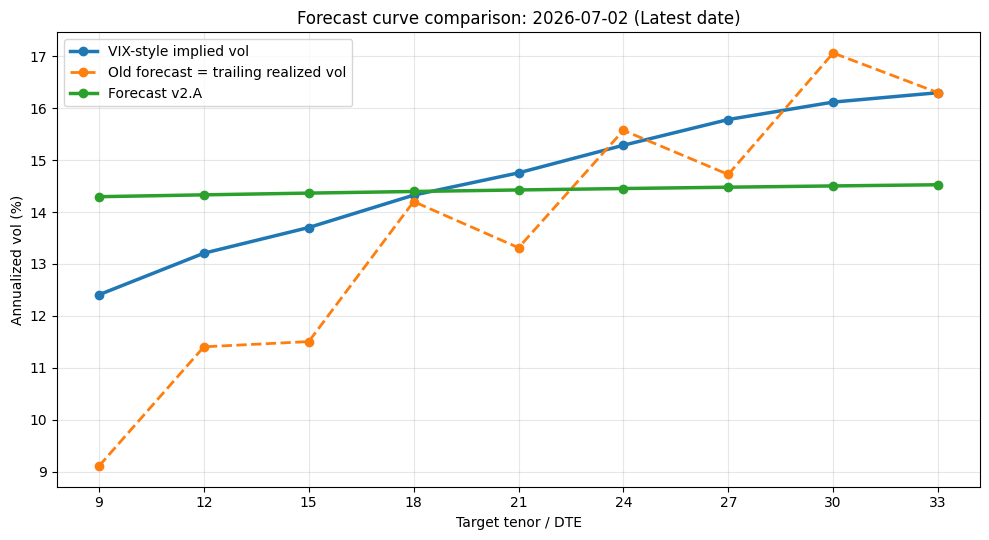

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vrp_comparison_20260702.png


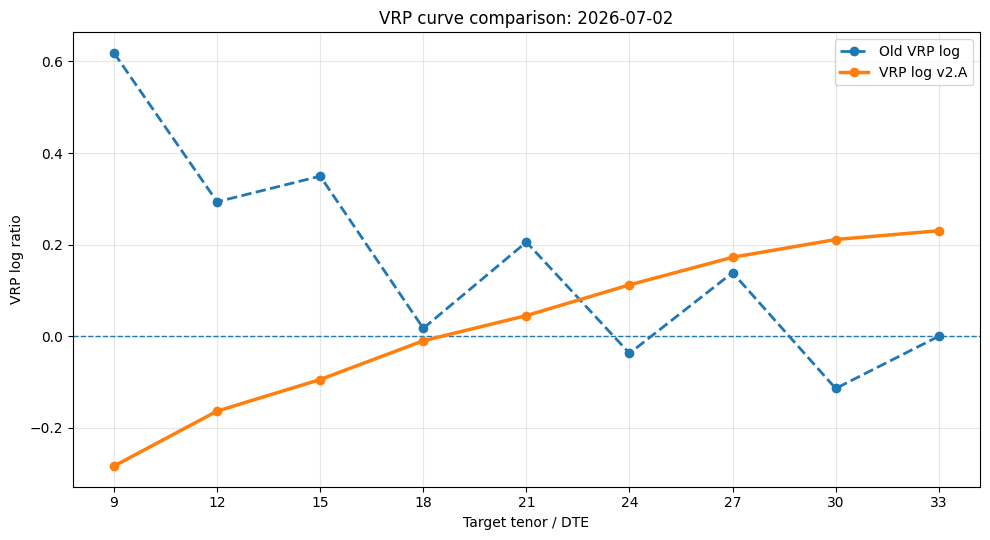

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vol_spread_comparison_20260702.png


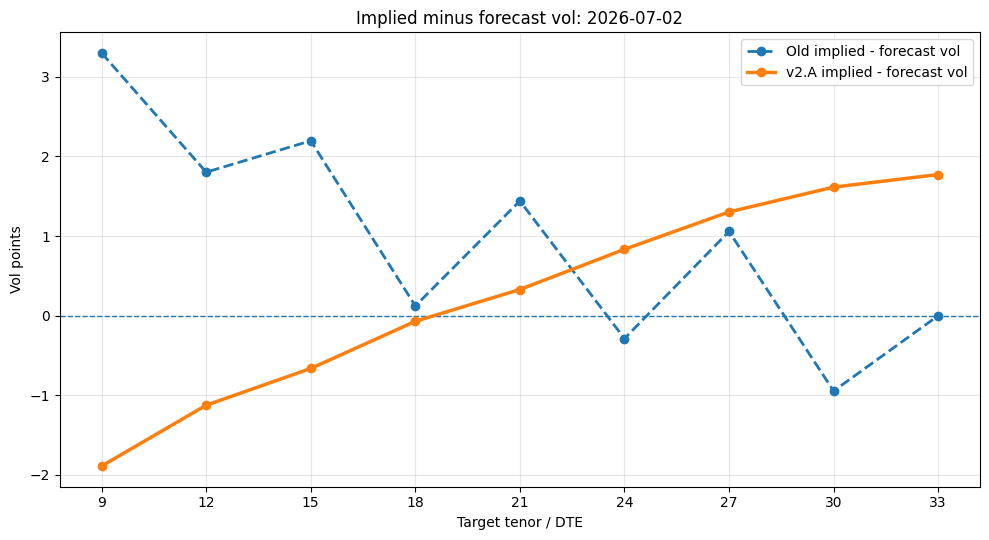


Known selected-trade test date: 2026-03-30
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_curve_comparison_20260330.png


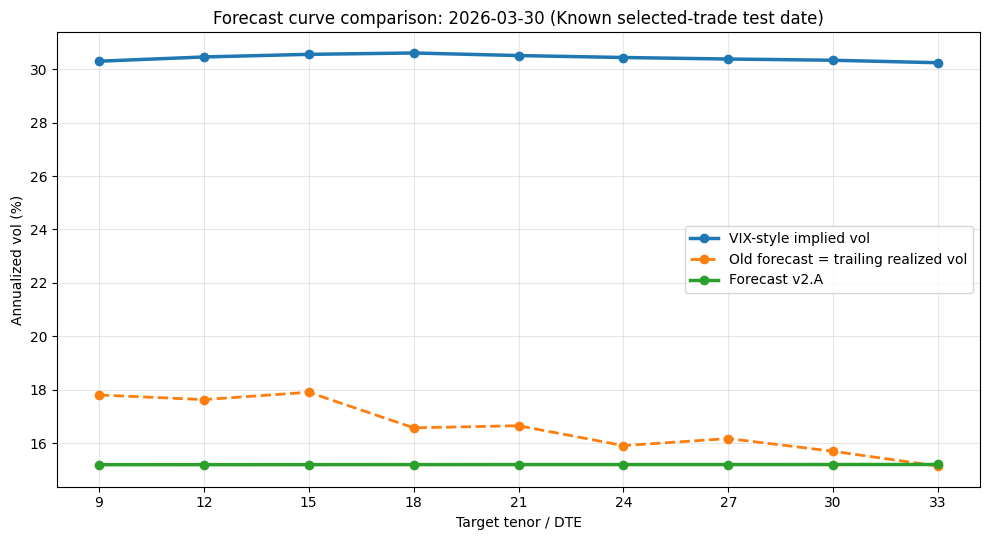

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vrp_comparison_20260330.png


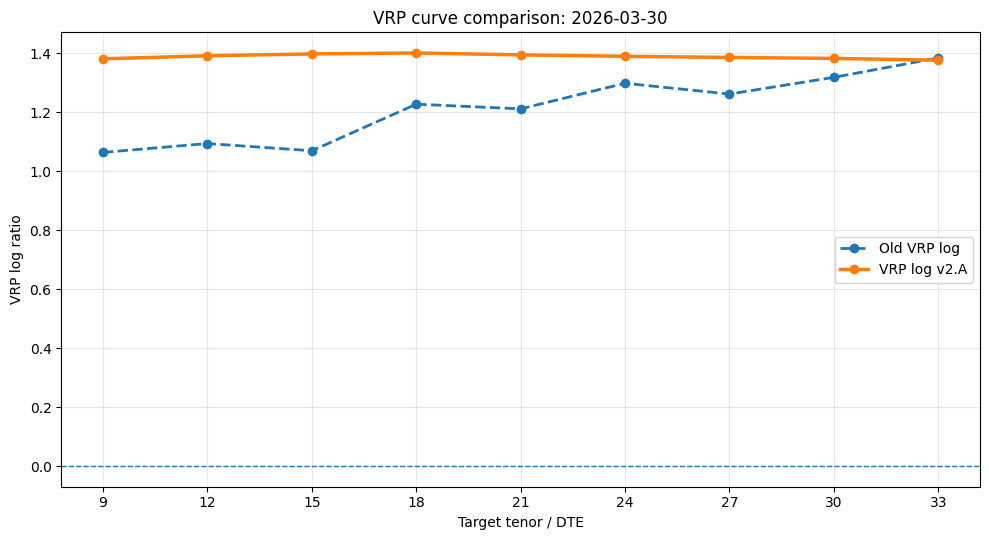

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vol_spread_comparison_20260330.png


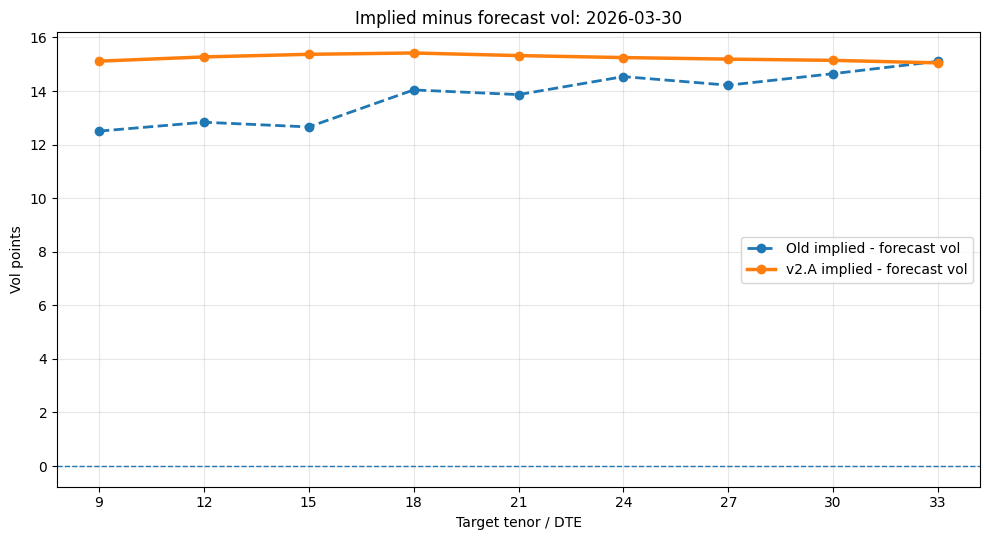


Highest v2.A current vol state: 2020-03-24
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_curve_comparison_20200324.png


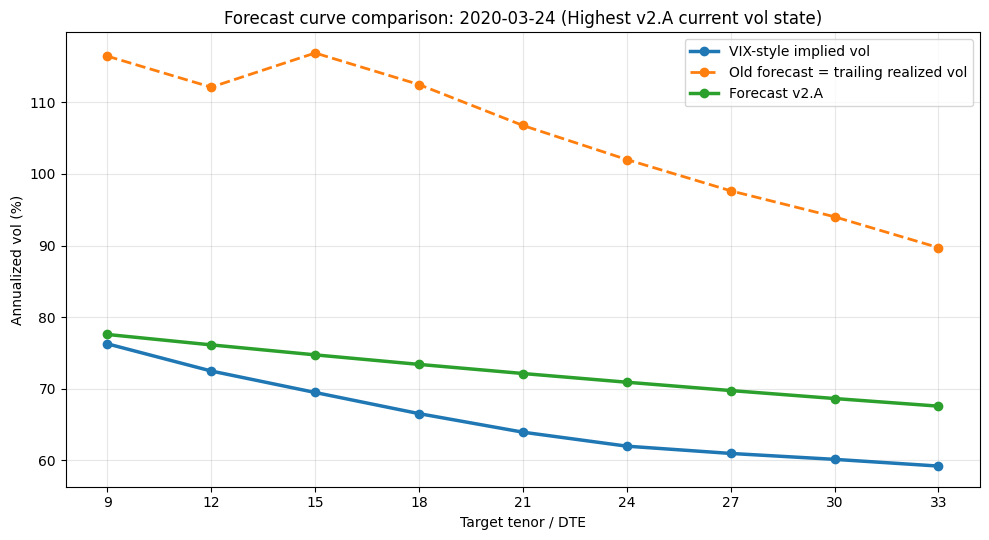

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vrp_comparison_20200324.png


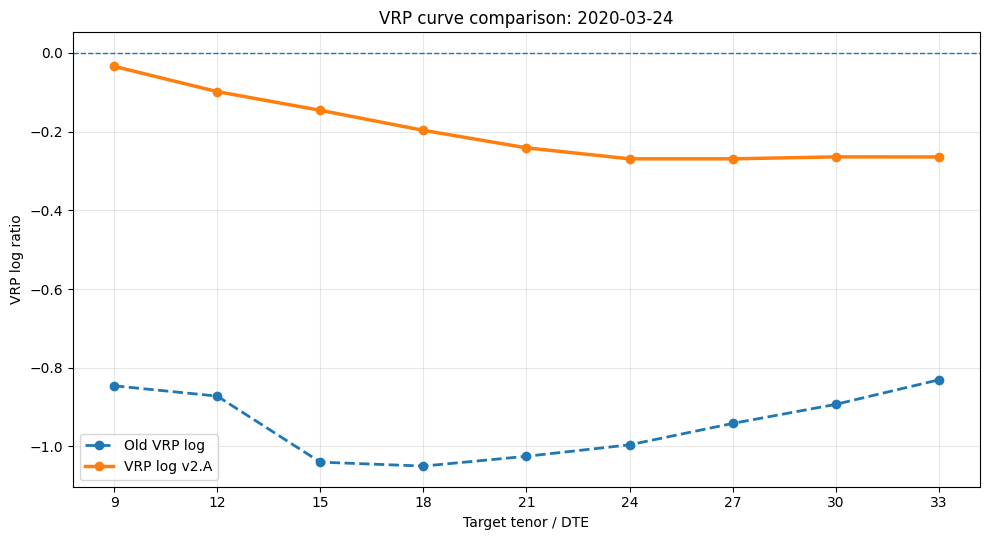

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vol_spread_comparison_20200324.png


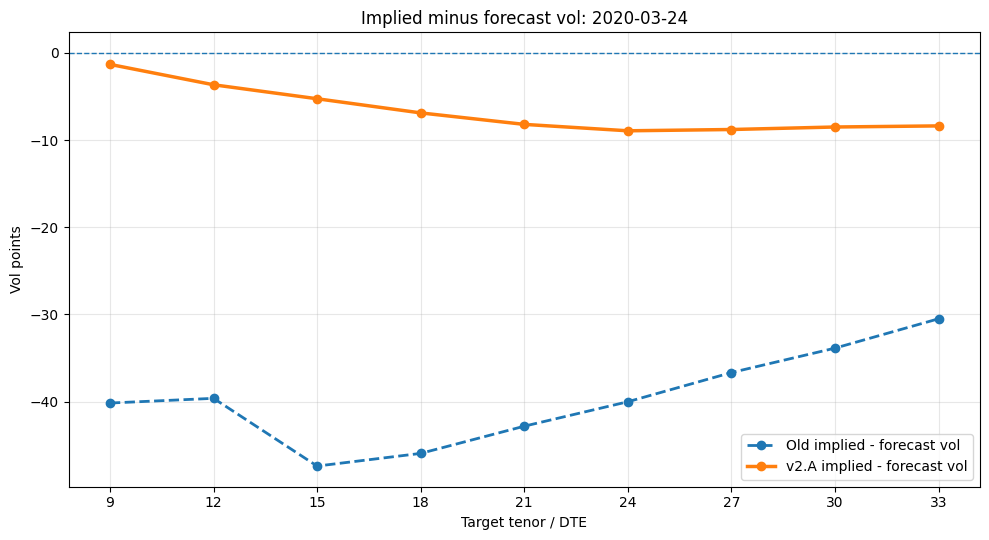


Lowest v2.A current vol state: 2018-10-03
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_curve_comparison_20181003.png


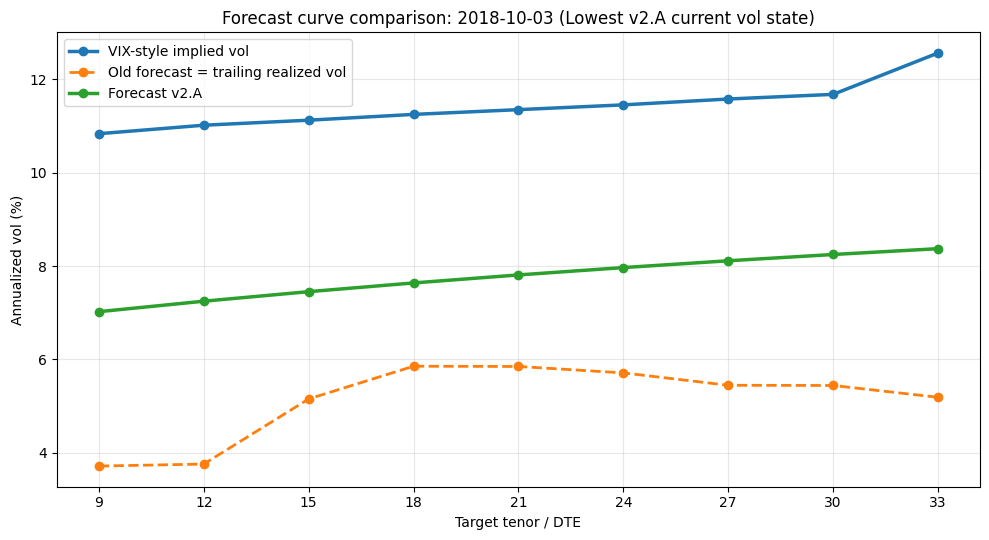

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vrp_comparison_20181003.png


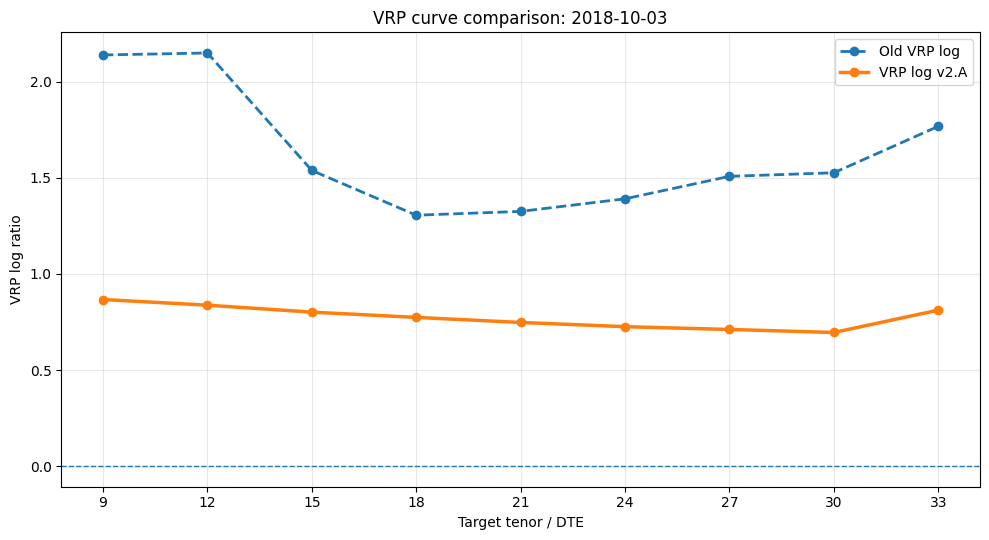

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vol_spread_comparison_20181003.png


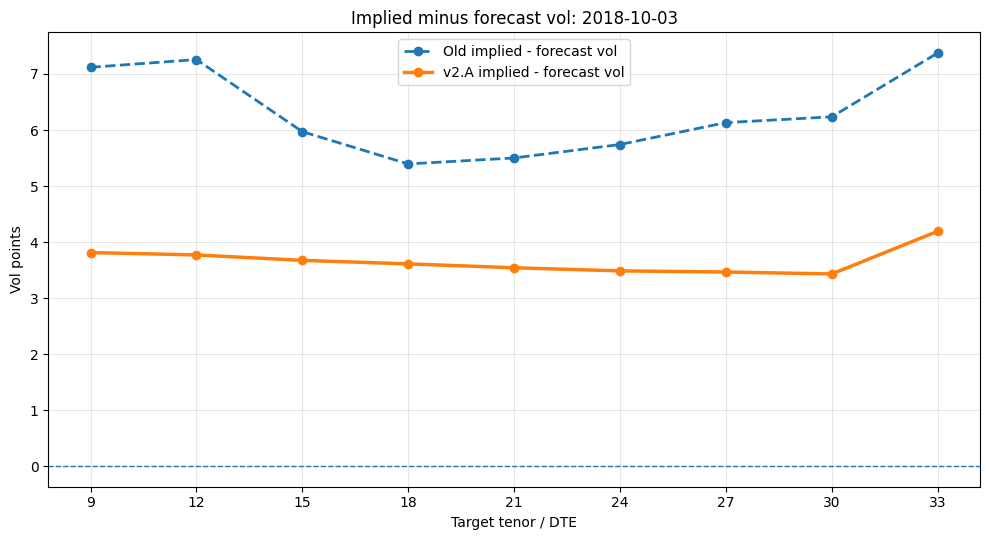


Largest SPX down-return date: 2020-03-16
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_curve_comparison_20200316.png


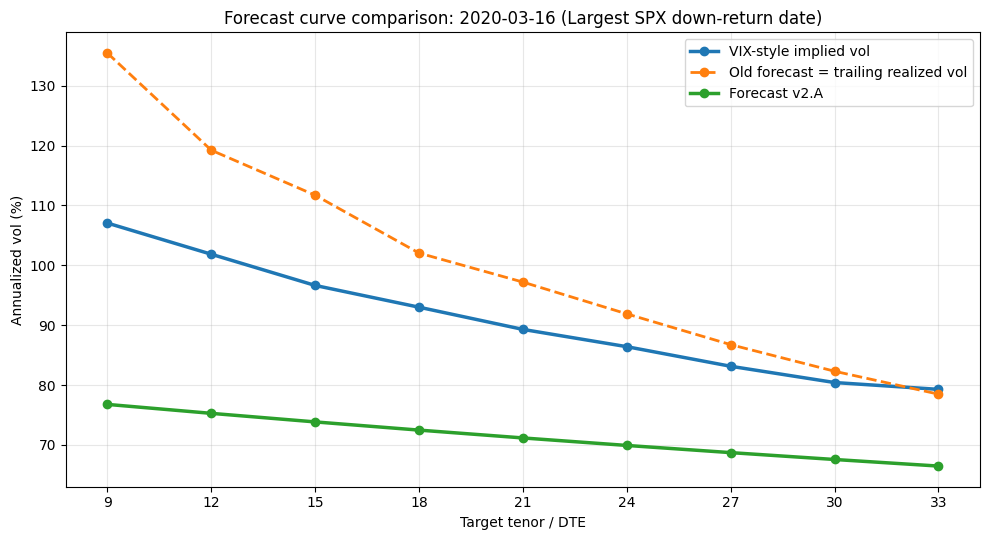

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vrp_comparison_20200316.png


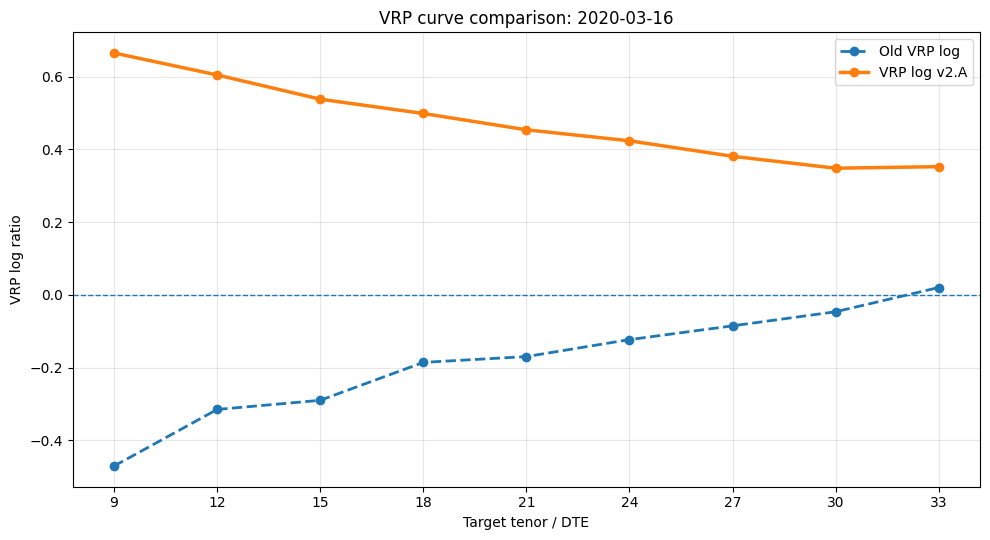

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_A_vol_spread_comparison_20200316.png


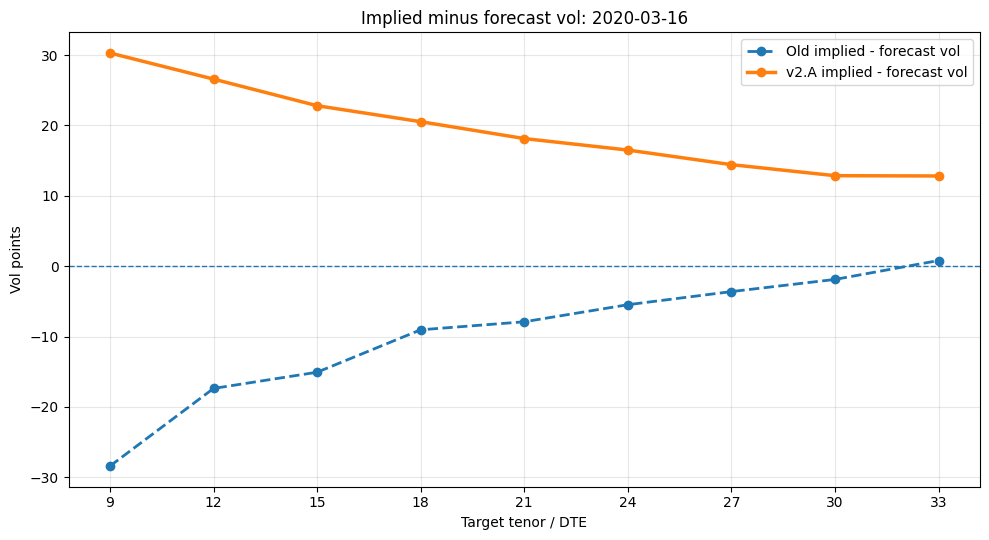


Representative curve summary:


,label,date,vix_style_vol_9d,vix_style_vol_33d,old_forecast_vol_9d,old_forecast_vol_33d,v2_A_forecast_vol_9d,v2_A_forecast_vol_33d,current_vol_state_v2_A,long_run_vol_anchor_v2_A,old_vrp_log_9d,old_vrp_log_33d,v2_A_vrp_log_9d,v2_A_vrp_log_33d
0,Latest date,2026-07-02,12.407236,16.298491,9.107617,16.298123,14.295553,14.525562,14.172878,15.058809,0.618337,0.000045,-0.283337,0.230325
1,Known selected-trade test date,2026-03-30,30.304077,30.246867,17.800484,15.137078,15.188527,15.195834,15.184677,15.213208,1.064113,1.384491,1.381484,1.376743
2,Highest v2.A current vol state,2020-03-24,76.282824,59.218490,116.441144,89.710250,77.590339,67.583267,82.374789,33.320496,-0.845876,-0.830702,-0.033990,-0.264253
3,Lowest v2.A current vol state,2018-10-03,10.835120,12.564000,3.715933,5.188882,7.023042,8.372591,6.194940,10.933670,2.140326,1.768635,0.867193,0.811745
4,Largest SPX down-return date,2020-03-16,107.055162,79.274362,135.465202,78.473872,76.762359,66.459356,81.669109,30.086931,-0.470741,0.020298,0.665260,0.352648



Forecast v2.A directional judgment:


,question,answer,evidence
0,Did v2.A fix the obvious jagged forecast curve?,Yes,"Latest avg adjacent move old=1.525, v2.A=0.029"
1,Is v2.A smoother than implied vol?,Yes,"Latest avg adjacent move implied=0.486, v2.A=0..."
2,Is v2.A possibly too flat?,Maybe,Latest 9D-to-33D v2.A forecast slope=0.230 vol...
3,Should v2.A replace production immediately?,No,It is directionally better as a forecast denom...



Cell 5 outputs saved:
Representative dates:          C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_A_representative_dates_20260703_202255.csv
Representative curve summary:  C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_A_representative_curve_summary_20260703_202255.csv
Directional judgment:          C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_A_directional_judgment_20260703_202255.csv
Charts folder:                 C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts

Cell 5 complete.
Next step will be Cell 6: test v2.A parameter sensitivity so the curve is smooth but not over-flattened.


In [5]:
# Cell 5: visualize old vs v2.A forecast curves
#
# Purpose:
# 1. Visually compare current production forecast vs v2.A.
# 2. Check whether v2.A is directionally acceptable.
# 3. Identify if v2.A is too flat and needs parameter tuning.
#
# This cell is research-only. It does not change production files.

import matplotlib.pyplot as plt

# -----------------------------
# 1. Chart output folder
# -----------------------------

FORECAST_V2_CHART_DIR = FORECAST_V2_AUDIT_DIR / "charts"
FORECAST_V2_CHART_DIR.mkdir(parents=True, exist_ok=True)

print(f"Chart output dir: {FORECAST_V2_CHART_DIR}")


# -----------------------------
# 2. Helper functions
# -----------------------------

def nearest_available_feature_date(requested_date, available_dates):
    """
    Pick the nearest available feature date on or before requested_date.
    """
    requested_date = pd.to_datetime(requested_date)
    available_dates = pd.to_datetime(pd.Series(available_dates)).sort_values()

    eligible = available_dates[available_dates <= requested_date]

    if len(eligible) == 0:
        return available_dates.iloc[0]

    return eligible.iloc[-1]


def format_date_for_filename(dt):
    return pd.to_datetime(dt).strftime("%Y%m%d")


def plot_forecast_curve_comparison(
    panel,
    selected_date,
    title_suffix="",
    save=True,
):
    """
    Plot implied vol, old forecast/trailing RV, and v2.A forecast across tenors.
    """
    selected_date = pd.to_datetime(selected_date)

    curve = (
        panel
        .loc[panel["date"] == selected_date]
        .sort_values("tenor")
        .copy()
    )

    if curve.empty:
        print(f"No curve found for {selected_date.date()}")
        return None

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.plot(
        curve["tenor"],
        curve["vix_style_vol"],
        marker="o",
        linewidth=2.5,
        label="VIX-style implied vol",
    )

    ax.plot(
        curve["tenor"],
        curve["forecast_vol_old"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Old forecast = trailing realized vol",
    )

    ax.plot(
        curve["tenor"],
        curve["forecast_vol_v2_A"],
        marker="o",
        linewidth=2.5,
        label="Forecast v2.A",
    )

    ax.set_title(f"Forecast curve comparison: {selected_date.date()} {title_suffix}".strip())
    ax.set_xlabel("Target tenor / DTE")
    ax.set_ylabel("Annualized vol (%)")
    ax.set_xticks(TARGET_TENORS)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if save:
        out = (
            FORECAST_V2_CHART_DIR
            / f"forecast_v2_A_curve_comparison_{format_date_for_filename(selected_date)}.png"
        )
        fig.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()

    return curve


def plot_vrp_curve_comparison(
    panel,
    selected_date,
    save=True,
):
    """
    Plot old VRP log vs v2.A VRP log across tenors.
    """
    selected_date = pd.to_datetime(selected_date)

    curve = (
        panel
        .loc[panel["date"] == selected_date]
        .sort_values("tenor")
        .copy()
    )

    if curve.empty:
        print(f"No curve found for {selected_date.date()}")
        return None

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.axhline(0, linewidth=1, linestyle="--")

    ax.plot(
        curve["tenor"],
        curve["vrp_log"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Old VRP log",
    )

    ax.plot(
        curve["tenor"],
        curve["vrp_log_v2_A"],
        marker="o",
        linewidth=2.5,
        label="VRP log v2.A",
    )

    ax.set_title(f"VRP curve comparison: {selected_date.date()}")
    ax.set_xlabel("Target tenor / DTE")
    ax.set_ylabel("VRP log ratio")
    ax.set_xticks(TARGET_TENORS)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if save:
        out = (
            FORECAST_V2_CHART_DIR
            / f"forecast_v2_A_vrp_comparison_{format_date_for_filename(selected_date)}.png"
        )
        fig.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()

    return curve


def plot_forecast_spread_curve(
    panel,
    selected_date,
    save=True,
):
    """
    Plot implied vol minus forecast vol for old method and v2.A.
    """
    selected_date = pd.to_datetime(selected_date)

    curve = (
        panel
        .loc[panel["date"] == selected_date]
        .sort_values("tenor")
        .copy()
    )

    if curve.empty:
        print(f"No curve found for {selected_date.date()}")
        return None

    curve["old_implied_minus_forecast_vol"] = (
        curve["vix_style_vol"] - curve["forecast_vol_old"]
    )

    curve["v2_A_implied_minus_forecast_vol"] = (
        curve["vix_style_vol"] - curve["forecast_vol_v2_A"]
    )

    fig, ax = plt.subplots(figsize=(10, 5.5))

    ax.axhline(0, linewidth=1, linestyle="--")

    ax.plot(
        curve["tenor"],
        curve["old_implied_minus_forecast_vol"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Old implied - forecast vol",
    )

    ax.plot(
        curve["tenor"],
        curve["v2_A_implied_minus_forecast_vol"],
        marker="o",
        linewidth=2.5,
        label="v2.A implied - forecast vol",
    )

    ax.set_title(f"Implied minus forecast vol: {selected_date.date()}")
    ax.set_xlabel("Target tenor / DTE")
    ax.set_ylabel("Vol points")
    ax.set_xticks(TARGET_TENORS)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    if save:
        out = (
            FORECAST_V2_CHART_DIR
            / f"forecast_v2_A_vol_spread_comparison_{format_date_for_filename(selected_date)}.png"
        )
        fig.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()

    return curve


# -----------------------------
# 3. Select representative dates
# -----------------------------

available_feature_dates = (
    forecast_v2_A_compare["date"]
    .dropna()
    .drop_duplicates()
    .sort_values()
)

latest_date = available_feature_dates.max()

# Highest and lowest v2.A current vol states
daily_state_available = (
    forecast_v2_A_compare[
        [
            "date",
            "current_vol_state_v2_A",
            "long_run_vol_anchor_v2_A",
            "spx_close",
            "spx_log_return",
        ]
    ]
    .drop_duplicates(subset=["date"])
    .dropna(subset=["current_vol_state_v2_A"])
    .sort_values("date")
    .copy()
)

highest_state_date = daily_state_available.loc[
    daily_state_available["current_vol_state_v2_A"].idxmax(),
    "date",
]

lowest_state_date = daily_state_available.loc[
    daily_state_available["current_vol_state_v2_A"].idxmin(),
    "date",
]

largest_down_return_date = daily_state_available.loc[
    daily_state_available["spx_log_return"].idxmin(),
    "date",
]

# Known useful signal-validation date from earlier production testing
known_trade_test_date = nearest_available_feature_date(
    "2026-03-30",
    available_feature_dates,
)

# A recent date around the latest dashboard issue
latest_dashboard_issue_date = latest_date

representative_dates = [
    {
        "label": "Latest date",
        "date": latest_dashboard_issue_date,
    },
    {
        "label": "Known selected-trade test date",
        "date": known_trade_test_date,
    },
    {
        "label": "Highest v2.A current vol state",
        "date": highest_state_date,
    },
    {
        "label": "Lowest v2.A current vol state",
        "date": lowest_state_date,
    },
    {
        "label": "Largest SPX down-return date",
        "date": largest_down_return_date,
    },
]

representative_dates_df = pd.DataFrame(representative_dates)
representative_dates_df["date"] = pd.to_datetime(representative_dates_df["date"])

print("Representative dates for visual inspection:")
display(representative_dates_df)


# -----------------------------
# 4. Plot representative curves
# -----------------------------

representative_curve_summaries = []

for _, row in representative_dates_df.iterrows():
    label = row["label"]
    dt = row["date"]

    print()
    print("=" * 90)
    print(f"{label}: {dt.date()}")
    print("=" * 90)

    curve = plot_forecast_curve_comparison(
        forecast_v2_A_compare,
        dt,
        title_suffix=f"({label})",
        save=True,
    )

    plot_vrp_curve_comparison(
        forecast_v2_A_compare,
        dt,
        save=True,
    )

    plot_forecast_spread_curve(
        forecast_v2_A_compare,
        dt,
        save=True,
    )

    if curve is not None:
        representative_curve_summaries.append({
            "label": label,
            "date": dt,
            "vix_style_vol_9d": curve.loc[curve["tenor"] == 9, "vix_style_vol"].iloc[0],
            "vix_style_vol_33d": curve.loc[curve["tenor"] == 33, "vix_style_vol"].iloc[0],
            "old_forecast_vol_9d": curve.loc[curve["tenor"] == 9, "forecast_vol_old"].iloc[0],
            "old_forecast_vol_33d": curve.loc[curve["tenor"] == 33, "forecast_vol_old"].iloc[0],
            "v2_A_forecast_vol_9d": curve.loc[curve["tenor"] == 9, "forecast_vol_v2_A"].iloc[0],
            "v2_A_forecast_vol_33d": curve.loc[curve["tenor"] == 33, "forecast_vol_v2_A"].iloc[0],
            "current_vol_state_v2_A": curve["current_vol_state_v2_A"].iloc[0],
            "long_run_vol_anchor_v2_A": curve["long_run_vol_anchor_v2_A"].iloc[0],
            "old_vrp_log_9d": curve.loc[curve["tenor"] == 9, "vrp_log"].iloc[0],
            "old_vrp_log_33d": curve.loc[curve["tenor"] == 33, "vrp_log"].iloc[0],
            "v2_A_vrp_log_9d": curve.loc[curve["tenor"] == 9, "vrp_log_v2_A"].iloc[0],
            "v2_A_vrp_log_33d": curve.loc[curve["tenor"] == 33, "vrp_log_v2_A"].iloc[0],
        })

representative_curve_summary_df = pd.DataFrame(representative_curve_summaries)

print()
print("Representative curve summary:")
display(representative_curve_summary_df)


# -----------------------------
# 5. Directional judgment table
# -----------------------------

# These are initial human-review flags, not final model decisions.
judgment_rows = []

latest_chop_old = latest_choppiness_v2_df.loc[
    latest_choppiness_v2_df["value_col"] == "forecast_vol_old",
    "avg_abs_adjacent_move",
].iloc[0]

latest_chop_new = latest_choppiness_v2_df.loc[
    latest_choppiness_v2_df["value_col"] == "forecast_vol_v2_A",
    "avg_abs_adjacent_move",
].iloc[0]

latest_chop_implied = latest_choppiness_v2_df.loc[
    latest_choppiness_v2_df["value_col"] == "vix_style_vol",
    "avg_abs_adjacent_move",
].iloc[0]

judgment_rows.append({
    "question": "Did v2.A fix the obvious jagged forecast curve?",
    "answer": "Yes" if latest_chop_new < latest_chop_old else "No",
    "evidence": f"Latest avg adjacent move old={latest_chop_old:.3f}, v2.A={latest_chop_new:.3f}",
})

judgment_rows.append({
    "question": "Is v2.A smoother than implied vol?",
    "answer": "Yes" if latest_chop_new < latest_chop_implied else "No",
    "evidence": f"Latest avg adjacent move implied={latest_chop_implied:.3f}, v2.A={latest_chop_new:.3f}",
})

latest_curve = (
    forecast_v2_A_compare
    .loc[forecast_v2_A_compare["date"] == latest_date]
    .sort_values("tenor")
    .copy()
)

latest_v2_A_slope_9_to_33 = (
    latest_curve.loc[latest_curve["tenor"] == 33, "forecast_vol_v2_A"].iloc[0]
    - latest_curve.loc[latest_curve["tenor"] == 9, "forecast_vol_v2_A"].iloc[0]
)

latest_implied_slope_9_to_33 = (
    latest_curve.loc[latest_curve["tenor"] == 33, "vix_style_vol"].iloc[0]
    - latest_curve.loc[latest_curve["tenor"] == 9, "vix_style_vol"].iloc[0]
)

judgment_rows.append({
    "question": "Is v2.A possibly too flat?",
    "answer": "Maybe",
    "evidence": (
        f"Latest 9D-to-33D v2.A forecast slope={latest_v2_A_slope_9_to_33:.3f} vol pts; "
        f"implied slope={latest_implied_slope_9_to_33:.3f} vol pts."
    ),
})

judgment_rows.append({
    "question": "Should v2.A replace production immediately?",
    "answer": "No",
    "evidence": (
        "It is directionally better as a forecast denominator, but thresholds and signal performance "
        "must be recalibrated before promotion."
    ),
})

forecast_v2_A_directional_judgment_df = pd.DataFrame(judgment_rows)

print()
print("Forecast v2.A directional judgment:")
display(forecast_v2_A_directional_judgment_df)


# -----------------------------
# 6. Save Cell 5 outputs
# -----------------------------

cell5_representative_dates_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_A_representative_dates_{RUN_TIMESTAMP}.csv"
)

cell5_representative_curve_summary_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_A_representative_curve_summary_{RUN_TIMESTAMP}.csv"
)

cell5_judgment_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_A_directional_judgment_{RUN_TIMESTAMP}.csv"
)

representative_dates_df.to_csv(cell5_representative_dates_output, index=False)
representative_curve_summary_df.to_csv(cell5_representative_curve_summary_output, index=False)
forecast_v2_A_directional_judgment_df.to_csv(cell5_judgment_output, index=False)

print()
print("Cell 5 outputs saved:")
print(f"Representative dates:          {cell5_representative_dates_output}")
print(f"Representative curve summary:  {cell5_representative_curve_summary_output}")
print(f"Directional judgment:          {cell5_judgment_output}")
print(f"Charts folder:                 {FORECAST_V2_CHART_DIR}")

print()
print("Cell 5 complete.")
print("Next step will be Cell 6: test v2.A parameter sensitivity so the curve is smooth but not over-flattened.")

In [6]:
# Cell 6: parameter sensitivity for EWMA mean-reverting forecast
#
# Purpose:
# v2.A fixed the jagged curve, but it may be too flat.
# This cell tests nearby EWMA / mean-reversion parameter sets to find a better balance:
#
#   smooth enough to be intuitive
#   responsive enough to recent volatility
#   term-structured enough to not be a flat line
#   no look-ahead
#
# This cell is research-only. It does not change production files.

# -----------------------------
# 1. Candidate parameter grid
# -----------------------------

# We are not optimizing yet.
# These are controlled parameter variations around v2.A.

sensitivity_specs = [
    {
        "candidate_id": "A00_base",
        "short_hl": 10,
        "medium_hl": 21,
        "long_hl": 126,
        "short_weight": 0.70,
        "medium_weight": 0.30,
        "mr_hl_cal_days": 21,
        "description": "Original v2.A baseline",
    },
    {
        "candidate_id": "A01_faster_mr_7d",
        "short_hl": 10,
        "medium_hl": 21,
        "long_hl": 126,
        "short_weight": 0.70,
        "medium_weight": 0.30,
        "mr_hl_cal_days": 7,
        "description": "Faster mean reversion; should create more term-structure slope",
    },
    {
        "candidate_id": "A02_faster_mr_14d",
        "short_hl": 10,
        "medium_hl": 21,
        "long_hl": 126,
        "short_weight": 0.70,
        "medium_weight": 0.30,
        "mr_hl_cal_days": 14,
        "description": "Moderately faster mean reversion",
    },
    {
        "candidate_id": "A03_slower_mr_42d",
        "short_hl": 10,
        "medium_hl": 21,
        "long_hl": 126,
        "short_weight": 0.70,
        "medium_weight": 0.30,
        "mr_hl_cal_days": 42,
        "description": "Slower mean reversion; should be flatter",
    },
    {
        "candidate_id": "A04_more_responsive_state",
        "short_hl": 5,
        "medium_hl": 21,
        "long_hl": 126,
        "short_weight": 0.85,
        "medium_weight": 0.15,
        "mr_hl_cal_days": 14,
        "description": "More responsive current variance state",
    },
    {
        "candidate_id": "A05_smoother_state",
        "short_hl": 15,
        "medium_hl": 42,
        "long_hl": 126,
        "short_weight": 0.60,
        "medium_weight": 0.40,
        "mr_hl_cal_days": 14,
        "description": "Smoother current variance state",
    },
    {
        "candidate_id": "A06_longer_anchor_252",
        "short_hl": 10,
        "medium_hl": 21,
        "long_hl": 252,
        "short_weight": 0.70,
        "medium_weight": 0.30,
        "mr_hl_cal_days": 14,
        "description": "Slower long-run anchor",
    },
    {
        "candidate_id": "A07_shorter_anchor_63",
        "short_hl": 10,
        "medium_hl": 21,
        "long_hl": 63,
        "short_weight": 0.70,
        "medium_weight": 0.30,
        "mr_hl_cal_days": 14,
        "description": "More responsive long-run anchor",
    },
    {
        "candidate_id": "A08_fast_state_fast_mr",
        "short_hl": 5,
        "medium_hl": 21,
        "long_hl": 126,
        "short_weight": 0.85,
        "medium_weight": 0.15,
        "mr_hl_cal_days": 7,
        "description": "High responsiveness plus faster mean reversion",
    },
    {
        "candidate_id": "A09_balanced_10_42_126_mr14",
        "short_hl": 10,
        "medium_hl": 42,
        "long_hl": 126,
        "short_weight": 0.75,
        "medium_weight": 0.25,
        "mr_hl_cal_days": 14,
        "description": "Balanced state with moderate term slope",
    },
    {
        "candidate_id": "A10_balanced_10_42_252_mr14",
        "short_hl": 10,
        "medium_hl": 42,
        "long_hl": 252,
        "short_weight": 0.75,
        "medium_weight": 0.25,
        "mr_hl_cal_days": 14,
        "description": "Balanced state with slower long-run anchor",
    },
    {
        "candidate_id": "A11_fast_state_slow_anchor_mr14",
        "short_hl": 5,
        "medium_hl": 21,
        "long_hl": 252,
        "short_weight": 0.80,
        "medium_weight": 0.20,
        "mr_hl_cal_days": 14,
        "description": "Responsive current state with slower long-run anchor",
    },
]

sensitivity_specs_df = pd.DataFrame(sensitivity_specs)

print("EWMA mean-reversion sensitivity candidates:")
display(sensitivity_specs_df)


# -----------------------------
# 2. Helper: build candidate forecast curve
# -----------------------------

def build_forecast_curve_for_spec(spx_input, feature_input, spec):
    """
    Build date x tenor forecast curve for one parameter specification.
    """
    state = spx_input.copy().sort_values("date").reset_index(drop=True)

    state_return = state["spx_log_return"]

    state["ewma_var_short_candidate"] = ewma_annualized_variance(
        state_return,
        spec["short_hl"],
    )

    state["ewma_var_medium_candidate"] = ewma_annualized_variance(
        state_return,
        spec["medium_hl"],
    )

    state["ewma_var_long_anchor_candidate"] = ewma_annualized_variance(
        state_return,
        spec["long_hl"],
    )

    state["current_variance_candidate"] = (
        spec["short_weight"] * state["ewma_var_short_candidate"]
        + spec["medium_weight"] * state["ewma_var_medium_candidate"]
    )

    state["anchor_variance_candidate"] = state["ewma_var_long_anchor_candidate"]

    state["current_vol_candidate"] = np.sqrt(state["current_variance_candidate"]) * 100
    state["anchor_vol_candidate"] = np.sqrt(state["anchor_variance_candidate"]) * 100

    feature_dates_local = (
        feature_input[["date", "trade_date"]]
        .drop_duplicates()
        .sort_values("date")
        .copy()
    )

    states_for_feature = feature_dates_local.merge(
        state[
            [
                "date",
                "current_variance_candidate",
                "anchor_variance_candidate",
                "current_vol_candidate",
                "anchor_vol_candidate",
            ]
        ],
        on="date",
        how="left",
        validate="one_to_one",
    )

    tenor_frame = pd.DataFrame({"tenor": TARGET_TENORS})
    states_for_feature["_tmp_key"] = 1
    tenor_frame["_tmp_key"] = 1

    curve = (
        states_for_feature
        .merge(tenor_frame, on="_tmp_key", how="inner")
        .drop(columns=["_tmp_key"])
        .copy()
    )

    tenor_frame.drop(columns=["_tmp_key"], inplace=True)

    curve["mr_weight_current"] = curve["tenor"].apply(
        lambda x: ou_average_variance_weight(
            x,
            spec["mr_hl_cal_days"],
        )
    )

    curve["forecast_variance_candidate"] = (
        curve["anchor_variance_candidate"]
        + (
            curve["current_variance_candidate"]
            - curve["anchor_variance_candidate"]
        )
        * curve["mr_weight_current"]
    )

    curve["forecast_vol_candidate"] = np.sqrt(curve["forecast_variance_candidate"]) * 100

    curve["candidate_id"] = spec["candidate_id"]
    curve["short_hl"] = spec["short_hl"]
    curve["medium_hl"] = spec["medium_hl"]
    curve["long_hl"] = spec["long_hl"]
    curve["short_weight"] = spec["short_weight"]
    curve["medium_weight"] = spec["medium_weight"]
    curve["mr_hl_cal_days"] = spec["mr_hl_cal_days"]
    curve["description"] = spec["description"]

    return curve


def summarize_candidate_curve(candidate_curve, feature_input, candidate_id):
    """
    Compute smoothness, slope, and forward-realized evaluation metrics.
    """
    latest_date_local = feature_input["date"].max()

    latest_curve_local = (
        candidate_curve
        .loc[candidate_curve["date"] == latest_date_local]
        .sort_values("tenor")
        .copy()
    )

    latest_chop = curve_choppiness_metrics(
        latest_curve_local,
        value_col="forecast_vol_candidate",
        tenor_col="tenor",
    )

    latest_9d = latest_curve_local.loc[
        latest_curve_local["tenor"] == 9,
        "forecast_vol_candidate",
    ].iloc[0]

    latest_33d = latest_curve_local.loc[
        latest_curve_local["tenor"] == 33,
        "forecast_vol_candidate",
    ].iloc[0]

    latest_slope_9d_33d = latest_33d - latest_9d

    latest_current_vol = latest_curve_local["current_vol_candidate"].iloc[0]
    latest_anchor_vol = latest_curve_local["anchor_vol_candidate"].iloc[0]

    # Historical choppiness
    ch = build_curve_choppiness_history(
        candidate_curve,
        value_cols=["forecast_vol_candidate"],
        date_col="date",
        tenor_col="tenor",
    )

    one_year_start_local = latest_date_local - pd.Timedelta(days=365)
    ch_last_year = ch.loc[ch["date"] >= one_year_start_local].copy()

    # Historical 9D-to-33D slope
    slope_panel = (
        candidate_curve
        .pivot_table(
            index="date",
            columns="tenor",
            values="forecast_vol_candidate",
            aggfunc="last",
        )
        .reset_index()
    )

    slope_panel["slope_9d_33d"] = slope_panel[33] - slope_panel[9]
    slope_panel["abs_slope_9d_33d"] = slope_panel["slope_9d_33d"].abs()

    slope_panel_last_year = slope_panel.loc[
        slope_panel["date"] >= one_year_start_local
    ].copy()

    # Forward-realized evaluation.
    # This uses future realized variance only for model evaluation, not for building the forecast.
    eval_panel = feature_input.merge(
        candidate_curve[
            [
                "date",
                "trade_date",
                "tenor",
                "forecast_variance_candidate",
                "forecast_vol_candidate",
            ]
        ],
        on=["date", "trade_date", "tenor"],
        how="left",
        validate="one_to_one",
    )

    eval_mask = (
        eval_panel["forecast_variance_candidate"].notna()
        & eval_panel["forward_realized_variance"].notna()
        & (eval_panel["forecast_variance_candidate"] > 0)
        & (eval_panel["forward_realized_variance"] > 0)
        & (eval_panel["forward_window_complete"] == True)
    )

    eval_complete = eval_panel.loc[eval_mask].copy()

    if len(eval_complete) > 0:
        eval_complete["abs_log_forecast_error"] = (
            np.log(
                eval_complete["forecast_variance_candidate"]
                / eval_complete["forward_realized_variance"]
            )
            .abs()
        )

        eval_complete["signed_log_forecast_error"] = np.log(
            eval_complete["forecast_variance_candidate"]
            / eval_complete["forward_realized_variance"]
        )

        forward_mae = eval_complete["abs_log_forecast_error"].mean()
        forward_median_abs = eval_complete["abs_log_forecast_error"].median()
        forward_bias = eval_complete["signed_log_forecast_error"].mean()
        forward_rows = len(eval_complete)
    else:
        forward_mae = np.nan
        forward_median_abs = np.nan
        forward_bias = np.nan
        forward_rows = 0

    out = {
        "candidate_id": candidate_id,
        "latest_forecast_vol_9d": latest_9d,
        "latest_forecast_vol_33d": latest_33d,
        "latest_slope_9d_33d": latest_slope_9d_33d,
        "latest_abs_slope_9d_33d": abs(latest_slope_9d_33d),
        "latest_current_vol": latest_current_vol,
        "latest_anchor_vol": latest_anchor_vol,
        "latest_avg_abs_adjacent_move": latest_chop["avg_abs_adjacent_move"],
        "latest_max_abs_adjacent_move": latest_chop["max_abs_adjacent_move"],
        "latest_slope_sign_changes": latest_chop["slope_sign_changes"],
        "latest_max_abs_second_diff": latest_chop["max_abs_second_diff"],
        "last_year_mean_avg_abs_adjacent_move": ch_last_year["avg_abs_adjacent_move"].mean(),
        "last_year_median_avg_abs_adjacent_move": ch_last_year["avg_abs_adjacent_move"].median(),
        "last_year_p95_avg_abs_adjacent_move": ch_last_year["avg_abs_adjacent_move"].quantile(0.95),
        "last_year_mean_slope_sign_changes": ch_last_year["slope_sign_changes"].mean(),
        "last_year_mean_abs_slope_9d_33d": slope_panel_last_year["abs_slope_9d_33d"].mean(),
        "last_year_median_abs_slope_9d_33d": slope_panel_last_year["abs_slope_9d_33d"].median(),
        "forward_eval_rows": forward_rows,
        "forward_abs_log_error_mean": forward_mae,
        "forward_abs_log_error_median": forward_median_abs,
        "forward_signed_log_error_mean_bias": forward_bias,
    }

    return out


# -----------------------------
# 3. Build old forecast benchmark row
# -----------------------------

latest_date = feature["date"].max()

old_latest_curve = (
    feature
    .loc[feature["date"] == latest_date]
    .sort_values("tenor")
    .copy()
)

old_latest_chop = curve_choppiness_metrics(
    old_latest_curve.rename(columns={"forecast_vol": "forecast_vol_old_for_metric"}),
    value_col="forecast_vol_old_for_metric",
    tenor_col="tenor",
)

old_latest_9d = old_latest_curve.loc[old_latest_curve["tenor"] == 9, "forecast_vol"].iloc[0]
old_latest_33d = old_latest_curve.loc[old_latest_curve["tenor"] == 33, "forecast_vol"].iloc[0]

old_chop_panel = feature.copy()
old_chop_panel["forecast_vol_old_for_metric"] = old_chop_panel["forecast_vol"]

old_chop_history = build_curve_choppiness_history(
    old_chop_panel,
    value_cols=["forecast_vol_old_for_metric"],
    date_col="date",
    tenor_col="tenor",
)

old_chop_last_year = old_chop_history.loc[
    old_chop_history["date"] >= latest_date - pd.Timedelta(days=365)
].copy()

old_slope_panel = (
    feature
    .pivot_table(
        index="date",
        columns="tenor",
        values="forecast_vol",
        aggfunc="last",
    )
    .reset_index()
)

old_slope_panel["slope_9d_33d"] = old_slope_panel[33] - old_slope_panel[9]
old_slope_panel["abs_slope_9d_33d"] = old_slope_panel["slope_9d_33d"].abs()

old_slope_last_year = old_slope_panel.loc[
    old_slope_panel["date"] >= latest_date - pd.Timedelta(days=365)
].copy()

old_eval_mask = (
    feature["forecast_variance"].notna()
    & feature["forward_realized_variance"].notna()
    & (feature["forecast_variance"] > 0)
    & (feature["forward_realized_variance"] > 0)
    & (feature["forward_window_complete"] == True)
)

old_eval = feature.loc[old_eval_mask].copy()
old_eval["abs_log_forecast_error"] = (
    np.log(old_eval["forecast_variance"] / old_eval["forward_realized_variance"]).abs()
)
old_eval["signed_log_forecast_error"] = np.log(
    old_eval["forecast_variance"] / old_eval["forward_realized_variance"]
)

old_benchmark_row = {
    "candidate_id": "OLD_trailing_realized_by_tenor",
    "latest_forecast_vol_9d": old_latest_9d,
    "latest_forecast_vol_33d": old_latest_33d,
    "latest_slope_9d_33d": old_latest_33d - old_latest_9d,
    "latest_abs_slope_9d_33d": abs(old_latest_33d - old_latest_9d),
    "latest_current_vol": np.nan,
    "latest_anchor_vol": np.nan,
    "latest_avg_abs_adjacent_move": old_latest_chop["avg_abs_adjacent_move"],
    "latest_max_abs_adjacent_move": old_latest_chop["max_abs_adjacent_move"],
    "latest_slope_sign_changes": old_latest_chop["slope_sign_changes"],
    "latest_max_abs_second_diff": old_latest_chop["max_abs_second_diff"],
    "last_year_mean_avg_abs_adjacent_move": old_chop_last_year["avg_abs_adjacent_move"].mean(),
    "last_year_median_avg_abs_adjacent_move": old_chop_last_year["avg_abs_adjacent_move"].median(),
    "last_year_p95_avg_abs_adjacent_move": old_chop_last_year["avg_abs_adjacent_move"].quantile(0.95),
    "last_year_mean_slope_sign_changes": old_chop_last_year["slope_sign_changes"].mean(),
    "last_year_mean_abs_slope_9d_33d": old_slope_last_year["abs_slope_9d_33d"].mean(),
    "last_year_median_abs_slope_9d_33d": old_slope_last_year["abs_slope_9d_33d"].median(),
    "forward_eval_rows": len(old_eval),
    "forward_abs_log_error_mean": old_eval["abs_log_forecast_error"].mean(),
    "forward_abs_log_error_median": old_eval["abs_log_forecast_error"].median(),
    "forward_signed_log_error_mean_bias": old_eval["signed_log_forecast_error"].mean(),
    "short_hl": np.nan,
    "medium_hl": np.nan,
    "long_hl": np.nan,
    "short_weight": np.nan,
    "medium_weight": np.nan,
    "mr_hl_cal_days": np.nan,
    "description": "Current production method: trailing realized vol by tenor",
}


# -----------------------------
# 4. Run sensitivity test
# -----------------------------

sensitivity_summary_rows = [old_benchmark_row]
sensitivity_curve_outputs = []

for spec in sensitivity_specs:
    print(f"Building candidate: {spec['candidate_id']}")

    curve = build_forecast_curve_for_spec(
        spx_input=spx,
        feature_input=feature,
        spec=spec,
    )

    summary = summarize_candidate_curve(
        candidate_curve=curve,
        feature_input=feature,
        candidate_id=spec["candidate_id"],
    )

    for key in [
        "short_hl",
        "medium_hl",
        "long_hl",
        "short_weight",
        "medium_weight",
        "mr_hl_cal_days",
        "description",
    ]:
        summary[key] = spec[key]

    sensitivity_summary_rows.append(summary)

    sensitivity_curve_outputs.append(curve)

forecast_v2_sensitivity_summary = pd.DataFrame(sensitivity_summary_rows)

forecast_v2_sensitivity_curves = pd.concat(
    sensitivity_curve_outputs,
    ignore_index=True,
)

print()
print("Sensitivity test complete.")
print(f"Candidate curves rows: {len(forecast_v2_sensitivity_curves):,}")


# -----------------------------
# 5. Rank candidates
# -----------------------------

# We do NOT want the absolute smoothest candidate automatically.
# We want:
# - materially smoother than old
# - no slope sign flipping
# - not absurdly flat
# - reasonable forward-realized error

summary = forecast_v2_sensitivity_summary.copy()

old_adj_move = summary.loc[
    summary["candidate_id"] == "OLD_trailing_realized_by_tenor",
    "last_year_mean_avg_abs_adjacent_move",
].iloc[0]

old_forward_error = summary.loc[
    summary["candidate_id"] == "OLD_trailing_realized_by_tenor",
    "forward_abs_log_error_mean",
].iloc[0]

summary["smoothness_improvement_vs_old"] = (
    old_adj_move / summary["last_year_mean_avg_abs_adjacent_move"]
)

summary["forward_error_improvement_vs_old"] = (
    old_forward_error - summary["forward_abs_log_error_mean"]
)

# Heuristic flags for review.
# These are not final model rules; they just organize the research table.
summary["is_candidate"] = summary["candidate_id"] != "OLD_trailing_realized_by_tenor"

summary["smooth_enough_flag"] = (
    summary["is_candidate"]
    & (summary["last_year_mean_avg_abs_adjacent_move"] < 0.40)
)

summary["too_flat_latest_flag"] = (
    summary["is_candidate"]
    & (summary["latest_abs_slope_9d_33d"] < 0.25)
)

summary["no_slope_flips_flag"] = (
    summary["is_candidate"]
    & (summary["last_year_mean_slope_sign_changes"] == 0)
)

summary["forward_error_better_than_old_flag"] = (
    summary["is_candidate"]
    & (summary["forward_abs_log_error_mean"] < old_forward_error)
)

summary["balanced_review_score"] = (
    0.40 * summary["forward_error_improvement_vs_old"].fillna(0)
    + 0.25 * np.log(summary["smoothness_improvement_vs_old"].replace([np.inf, -np.inf], np.nan)).fillna(0)
    + 0.20 * summary["no_slope_flips_flag"].astype(int)
    + 0.15 * (~summary["too_flat_latest_flag"]).astype(int)
)

summary = summary.sort_values(
    ["is_candidate", "balanced_review_score"],
    ascending=[False, False],
).reset_index(drop=True)

forecast_v2_sensitivity_ranked = summary.copy()

display_cols = [
    "candidate_id",
    "description",
    "short_hl",
    "medium_hl",
    "long_hl",
    "short_weight",
    "medium_weight",
    "mr_hl_cal_days",
    "latest_forecast_vol_9d",
    "latest_forecast_vol_33d",
    "latest_slope_9d_33d",
    "latest_avg_abs_adjacent_move",
    "latest_slope_sign_changes",
    "last_year_mean_avg_abs_adjacent_move",
    "last_year_mean_abs_slope_9d_33d",
    "forward_abs_log_error_mean",
    "forward_signed_log_error_mean_bias",
    "smoothness_improvement_vs_old",
    "forward_error_improvement_vs_old",
    "too_flat_latest_flag",
    "balanced_review_score",
]

print()
print("Forecast v2 sensitivity ranked summary:")
display(forecast_v2_sensitivity_ranked[display_cols])


# -----------------------------
# 6. Show top candidates separately
# -----------------------------

top_balanced_candidates = (
    forecast_v2_sensitivity_ranked
    .loc[forecast_v2_sensitivity_ranked["is_candidate"]]
    .head(5)
    .copy()
)

top_forward_error_candidates = (
    forecast_v2_sensitivity_ranked
    .loc[forecast_v2_sensitivity_ranked["is_candidate"]]
    .sort_values("forward_abs_log_error_mean")
    .head(5)
    .copy()
)

top_slope_candidates = (
    forecast_v2_sensitivity_ranked
    .loc[
        forecast_v2_sensitivity_ranked["is_candidate"]
        & (~forecast_v2_sensitivity_ranked["too_flat_latest_flag"])
    ]
    .sort_values("last_year_mean_avg_abs_adjacent_move")
    .head(5)
    .copy()
)

print()
print("Top 5 balanced candidates:")
display(top_balanced_candidates[display_cols])

print()
print("Top 5 by forward-realized error:")
display(top_forward_error_candidates[display_cols])

print()
print("Smooth candidates that are not flagged as too flat:")
display(top_slope_candidates[display_cols])


# -----------------------------
# 7. Latest curve table for top candidates
# -----------------------------

top_candidate_ids = top_balanced_candidates["candidate_id"].tolist()

latest_top_curves = (
    forecast_v2_sensitivity_curves
    .loc[
        (forecast_v2_sensitivity_curves["date"] == latest_date)
        & (forecast_v2_sensitivity_curves["candidate_id"].isin(top_candidate_ids))
    ]
    .sort_values(["candidate_id", "tenor"])
    .copy()
)

latest_top_curve_table = latest_top_curves[
    [
        "candidate_id",
        "tenor",
        "forecast_vol_candidate",
        "current_vol_candidate",
        "anchor_vol_candidate",
        "mr_weight_current",
        "short_hl",
        "medium_hl",
        "long_hl",
        "short_weight",
        "mr_hl_cal_days",
    ]
].copy()

print()
print(f"Latest curve table for top balanced candidates: {latest_date.date()}")
display(latest_top_curve_table)


# -----------------------------
# 8. Save Cell 6 outputs
# -----------------------------

cell6_specs_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell6_sensitivity_specs_{RUN_TIMESTAMP}.csv"
)

cell6_ranked_summary_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell6_sensitivity_ranked_summary_{RUN_TIMESTAMP}.csv"
)

cell6_top_latest_curve_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell6_top_latest_curve_table_{RUN_TIMESTAMP}.csv"
)

cell6_curves_output = (
    FORECAST_V2_DIR
    / f"forecast_v2_cell6_sensitivity_curves_{RUN_TIMESTAMP}.parquet"
)

sensitivity_specs_df.to_csv(cell6_specs_output, index=False)
forecast_v2_sensitivity_ranked.to_csv(cell6_ranked_summary_output, index=False)
latest_top_curve_table.to_csv(cell6_top_latest_curve_output, index=False)
forecast_v2_sensitivity_curves.to_parquet(cell6_curves_output, index=False)

print()
print("Cell 6 outputs saved:")
print(f"Sensitivity specs:          {cell6_specs_output}")
print(f"Ranked summary:             {cell6_ranked_summary_output}")
print(f"Top latest curve table:     {cell6_top_latest_curve_output}")
print(f"All candidate curves:       {cell6_curves_output}")

print()
print("Cell 6 complete.")
print("Next step will be Cell 7: plot the top candidate curves side-by-side and choose a working candidate for deeper validation.")

EWMA mean-reversion sensitivity candidates:


,candidate_id,short_hl,medium_hl,long_hl,short_weight,medium_weight,mr_hl_cal_days,description
0,A00_base,10,21,126,0.70,0.30,21,Original v2.A baseline
1,A01_faster_mr_7d,10,21,126,0.70,0.30,7,Faster mean reversion; should create more term...
2,A02_faster_mr_14d,10,21,126,0.70,0.30,14,Moderately faster mean reversion
3,A03_slower_mr_42d,10,21,126,0.70,0.30,42,Slower mean reversion; should be flatter
4,A04_more_responsive_state,5,21,126,0.85,0.15,14,More responsive current variance state
5,A05_smoother_state,15,42,126,0.60,0.40,14,Smoother current variance state
6,A06_longer_anchor_252,10,21,252,0.70,0.30,14,Slower long-run anchor
7,A07_shorter_anchor_63,10,21,63,0.70,0.30,14,More responsive long-run anchor
8,A08_fast_state_fast_mr,5,21,126,0.85,0.15,7,High responsiveness plus faster mean reversion
9,A09_balanced_10_42_126_mr14,10,42,126,0.75,0.25,14,Balanced state with moderate term slope


Building candidate: A00_base
Building candidate: A01_faster_mr_7d
Building candidate: A02_faster_mr_14d
Building candidate: A03_slower_mr_42d
Building candidate: A04_more_responsive_state
Building candidate: A05_smoother_state
Building candidate: A06_longer_anchor_252
Building candidate: A07_shorter_anchor_63
Building candidate: A08_fast_state_fast_mr
Building candidate: A09_balanced_10_42_126_mr14
Building candidate: A10_balanced_10_42_252_mr14
Building candidate: A11_fast_state_slow_anchor_mr14

Sensitivity test complete.
Candidate curves rows: 217,728

Forecast v2 sensitivity ranked summary:


,candidate_id,description,short_hl,medium_hl,long_hl,short_weight,medium_weight,mr_hl_cal_days,latest_forecast_vol_9d,latest_forecast_vol_33d,...,latest_avg_abs_adjacent_move,latest_slope_sign_changes,last_year_mean_avg_abs_adjacent_move,last_year_mean_abs_slope_9d_33d,forward_abs_log_error_mean,forward_signed_log_error_mean_bias,smoothness_improvement_vs_old,forward_error_improvement_vs_old,too_flat_latest_flag,balanced_review_score
0,A05_smoother_state,Smoother current variance state,15.0,42.0,126.0,0.60,0.40,14.0,14.421089,14.672799,...,0.031464,0,0.110618,0.884947,0.803692,0.418073,7.672708,-0.070036,False,0.831403
1,A09_balanced_10_42_126_mr14,Balanced state with moderate term slope,10.0,42.0,126.0,0.75,0.25,14.0,14.312964,14.608024,...,0.036883,0,0.142817,1.142537,0.771090,0.394084,5.942861,-0.037435,False,0.780574
2,A03_slower_mr_42d,Slower mean reversion; should be flatter,10.0,21.0,126.0,0.70,0.30,42.0,14.237344,14.380515,...,0.017896,0,0.089404,0.715229,0.720127,0.284807,9.493371,0.013529,True,0.768060
3,A10_balanced_10_42_252_mr14,Balanced state with slower long-run anchor,10.0,42.0,252.0,0.75,0.25,14.0,14.500938,15.087335,...,0.073300,0,0.157382,1.259055,0.768044,0.408511,5.392885,-0.034389,False,0.757515
4,A02_faster_mr_14d,Moderately faster mean reversion,10.0,21.0,126.0,0.70,0.30,14.0,14.348201,14.629112,...,0.035114,0,0.162315,1.298518,0.760679,0.377592,5.228989,-0.027024,False,0.752745
5,A06_longer_anchor_252,Slower long-run anchor,10.0,21.0,252.0,0.70,0.30,14.0,14.535719,15.107754,...,0.071504,0,0.176499,1.411995,0.757529,0.391446,4.808754,-0.023873,False,0.733060
6,A04_more_responsive_state,More responsive current variance state,5.0,21.0,126.0,0.85,0.15,14.0,13.539018,14.150449,...,0.076429,0,0.191118,1.528941,0.726973,0.348157,4.440941,0.006683,False,0.725390
7,A11_fast_state_slow_anchor_mr14,Responsive current state with slower long-run ...,5.0,21.0,252.0,0.80,0.20,14.0,13.793840,14.676989,...,0.110394,0,0.199049,1.592391,0.726880,0.364811,4.263987,0.006776,False,0.715261
8,A01_faster_mr_7d,Faster mean reversion; should create more term...,10.0,21.0,126.0,0.70,0.30,7.0,14.478524,14.803527,...,0.040625,0,0.178041,1.424327,0.804399,0.439872,4.767121,-0.070743,False,0.712138
9,A08_fast_state_fast_mr,High responsiveness plus faster mean reversion,5.0,21.0,126.0,0.85,0.15,7.0,13.824567,14.522817,...,0.087281,0,0.206930,1.655442,0.776249,0.425120,4.101585,-0.042593,False,0.685806



Top 5 balanced candidates:


...


Smooth candidates that are not flagged as too flat:


,candidate_id,description,short_hl,medium_hl,long_hl,short_weight,medium_weight,mr_hl_cal_days,latest_forecast_vol_9d,latest_forecast_vol_33d,...,latest_avg_abs_adjacent_move,latest_slope_sign_changes,last_year_mean_avg_abs_adjacent_move,last_year_mean_abs_slope_9d_33d,forward_abs_log_error_mean,forward_signed_log_error_mean_bias,smoothness_improvement_vs_old,forward_error_improvement_vs_old,too_flat_latest_flag,balanced_review_score
0,A05_smoother_state,Smoother current variance state,15.0,42.0,126.0,0.60,0.40,14.0,14.421089,14.672799,...,0.031464,0,0.110618,0.884947,0.803692,0.418073,7.672708,-0.070036,False,0.831403
1,A09_balanced_10_42_126_mr14,Balanced state with moderate term slope,10.0,42.0,126.0,0.75,0.25,14.0,14.312964,14.608024,...,0.036883,0,0.142817,1.142537,0.771090,0.394084,5.942861,-0.037435,False,0.780574
3,A10_balanced_10_42_252_mr14,Balanced state with slower long-run anchor,10.0,42.0,252.0,0.75,0.25,14.0,14.500938,15.087335,...,0.073300,0,0.157382,1.259055,0.768044,0.408511,5.392885,-0.034389,False,0.757515
4,A02_faster_mr_14d,Moderately faster mean reversion,10.0,21.0,126.0,0.70,0.30,14.0,14.348201,14.629112,...,0.035114,0,0.162315,1.298518,0.760679,0.377592,5.228989,-0.027024,False,0.752745
5,A06_longer_anchor_252,Slower long-run anchor,10.0,21.0,252.0,0.70,0.30,14.0,14.535719,15.107754,...,0.071504,0,0.176499,1.411995,0.757529,0.391446,4.808754,-0.023873,False,0.733060



Latest curve table for top balanced candidates: 2026-07-02


,candidate_id,tenor,forecast_vol_candidate,current_vol_candidate,anchor_vol_candidate,mr_weight_current,short_hl,medium_hl,long_hl,short_weight,mr_hl_cal_days
54423,A02_faster_mr_14d,9,14.348201,14.172878,15.058809,0.806914,10,21,126,0.70,14
54424,A02_faster_mr_14d,12,14.395898,14.172878,15.058809,0.753973,10,21,126,0.70,14
54425,A02_faster_mr_14d,15,14.439182,14.172878,15.058809,0.705779,10,21,126,0.70,14
54426,A02_faster_mr_14d,18,14.478524,14.172878,15.058809,0.661849,10,21,126,0.70,14
54427,A02_faster_mr_14d,21,14.514341,14.172878,15.058809,0.621750,10,21,126,0.70,14
54428,A02_faster_mr_14d,24,14.547001,14.172878,15.058809,0.585100,10,21,126,0.70,14
54429,A02_faster_mr_14d,27,14.576829,14.172878,15.058809,0.551556,10,21,126,0.70,14
54430,A02_faster_mr_14d,30,14.604114,14.172878,15.058809,0.520811,10,21,126,0.70,14
54431,A02_faster_mr_14d,33,14.629112,14.172878,15.058809,0.492594,10,21,126,0.70,14
72567,A03_slower_mr_42d,9,14.237344,14.172878,15.058809,0.929279,10,21,126,0.70,42



Cell 6 outputs saved:
Sensitivity specs:          C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell6_sensitivity_specs_20260703_202255.csv
Ranked summary:             C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell6_sensitivity_ranked_summary_20260703_202255.csv
Top latest curve table:     C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell6_top_latest_curve_table_20260703_202255.csv
All candidate curves:       C:\Users\patri\vrp_project\data\processed\forecast_model_research_v2\forecast_v2_cell6_sensitivity_curves_20260703_202255.parquet

Cell 6 complete.
Next step will be Cell 7: plot the top candidate curves side-by-side and choose a working candidate for deeper validation.


Candidate shortlist for visual review:


,candidate_id,description,short_hl,medium_hl,long_hl,short_weight,medium_weight,mr_hl_cal_days,latest_forecast_vol_9d,latest_forecast_vol_33d,latest_slope_9d_33d,last_year_mean_avg_abs_adjacent_move,last_year_mean_abs_slope_9d_33d,forward_abs_log_error_mean,forward_signed_log_error_mean_bias,too_flat_latest_flag,balanced_review_score
0,A05_smoother_state,Smoother current variance state,15.0,42.0,126.0,0.60,0.40,14.0,14.421089,14.672799,0.251710,0.110618,0.884947,0.803692,0.418073,False,0.831403
1,A09_balanced_10_42_126_mr14,Balanced state with moderate term slope,10.0,42.0,126.0,0.75,0.25,14.0,14.312964,14.608024,0.295061,0.142817,1.142537,0.771090,0.394084,False,0.780574
2,A03_slower_mr_42d,Slower mean reversion; should be flatter,10.0,21.0,126.0,0.70,0.30,42.0,14.237344,14.380515,0.143171,0.089404,0.715229,0.720127,0.284807,True,0.768060
3,A10_balanced_10_42_252_mr14,Balanced state with slower long-run anchor,10.0,42.0,252.0,0.75,0.25,14.0,14.500938,15.087335,0.586398,0.157382,1.259055,0.768044,0.408511,False,0.757515
4,A02_faster_mr_14d,Moderately faster mean reversion,10.0,21.0,126.0,0.70,0.30,14.0,14.348201,14.629112,0.280911,0.162315,1.298518,0.760679,0.377592,False,0.752745
6,A04_more_responsive_state,More responsive current variance state,5.0,21.0,126.0,0.85,0.15,14.0,13.539018,14.150449,0.611432,0.191118,1.528941,0.726973,0.348157,False,0.725390
7,A11_fast_state_slow_anchor_mr14,Responsive current state with slower long-run ...,5.0,21.0,252.0,0.80,0.20,14.0,13.793840,14.676989,0.883148,0.199049,1.592391,0.726880,0.364811,False,0.715261



Dates used for candidate curve plots:


,label,date
0,Latest date,2026-07-02
1,Known selected-trade test date,2026-03-30
2,Highest v2.A current vol state,2020-03-24
3,Lowest v2.A current vol state,2018-10-03
4,Largest SPX down-return date,2020-03-16



Latest date: 2026-07-02
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_forecast_curves_latest_date_20260702.png


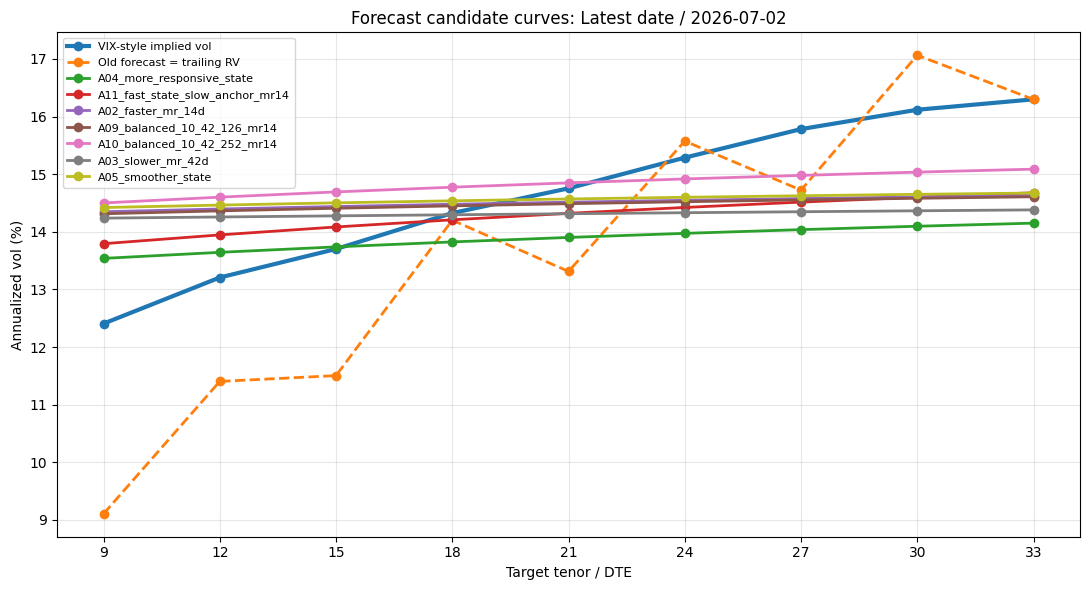

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vrp_curves_latest_date_20260702.png


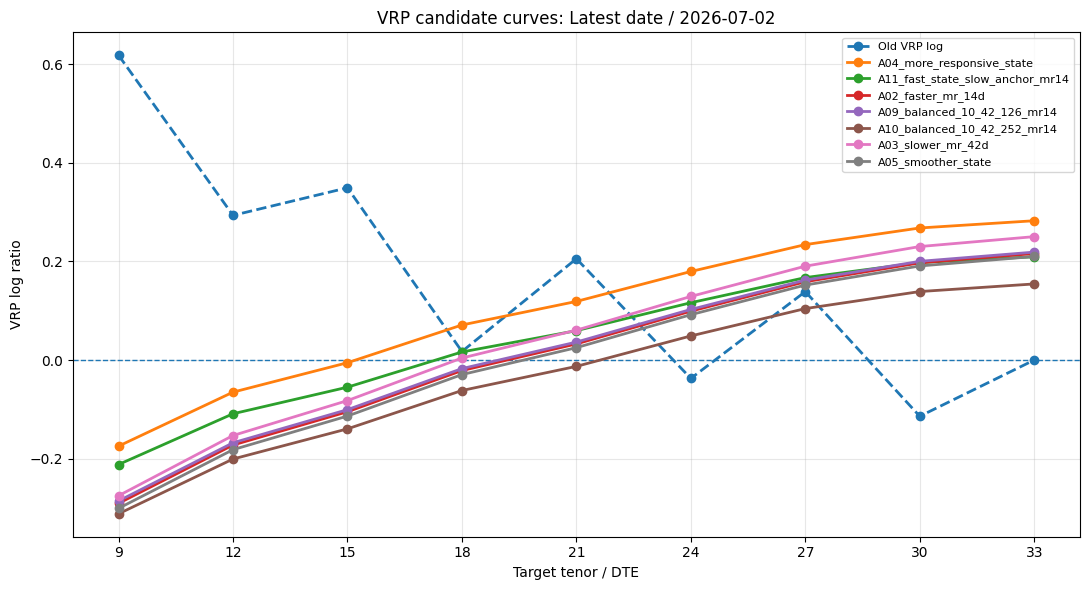

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vol_spread_latest_date_20260702.png


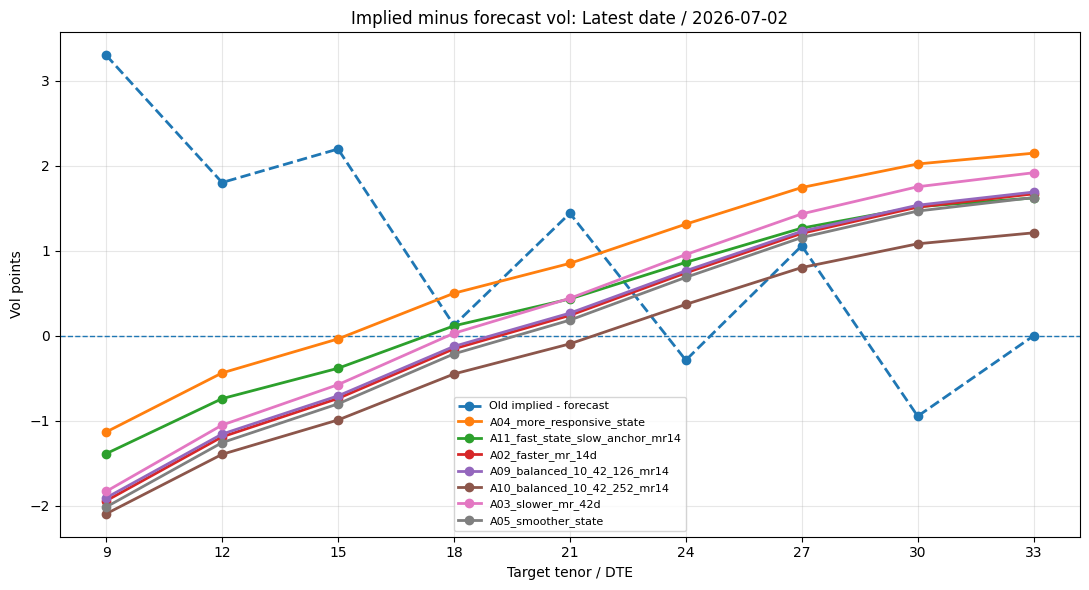


Known selected-trade test date: 2026-03-30
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_forecast_curves_known_selected-trade_test_date_20260330.png


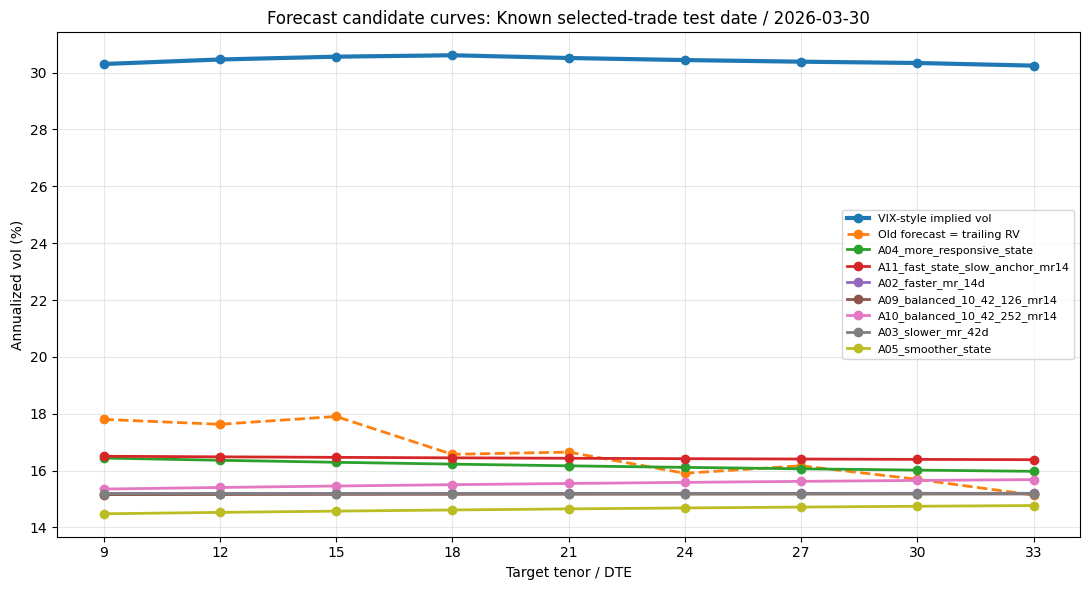

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vrp_curves_known_selected-trade_test_date_20260330.png


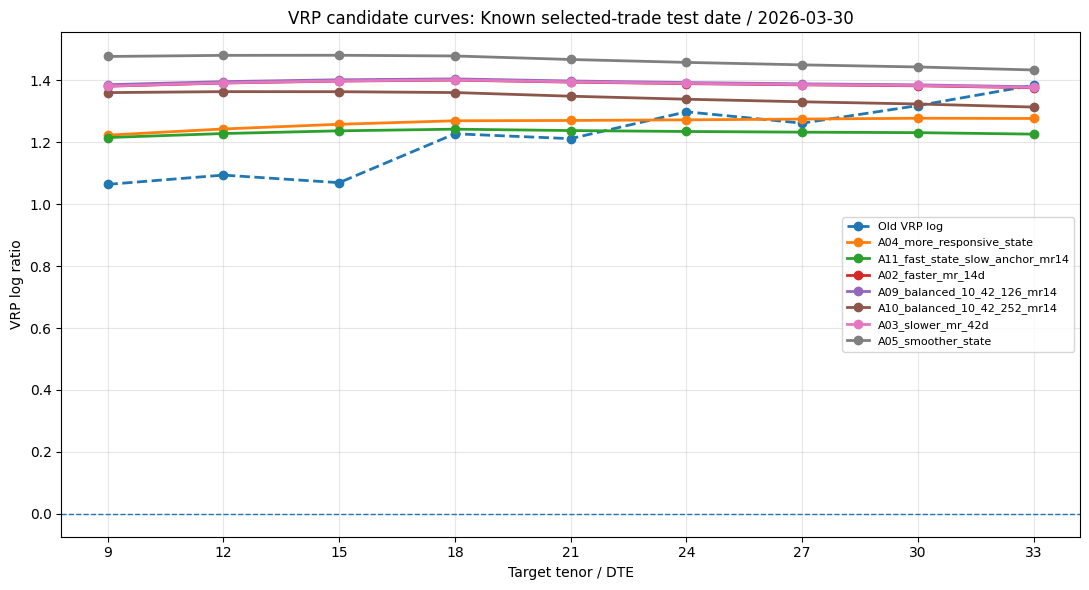

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vol_spread_known_selected-trade_test_date_20260330.png


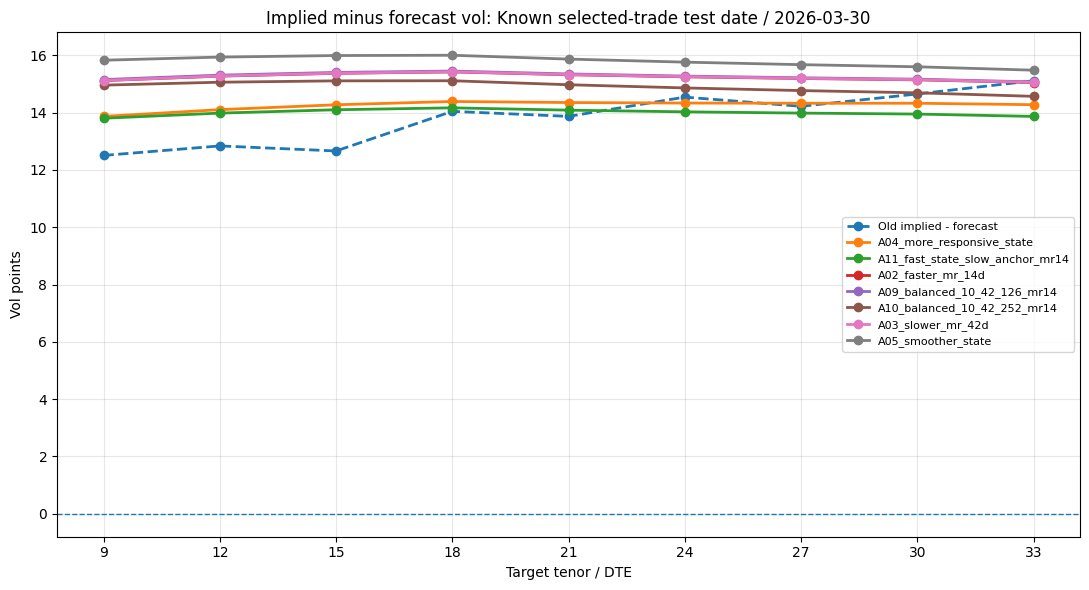


Highest v2.A current vol state: 2020-03-24
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_forecast_curves_highest_v2.a_current_vol_state_20200324.png


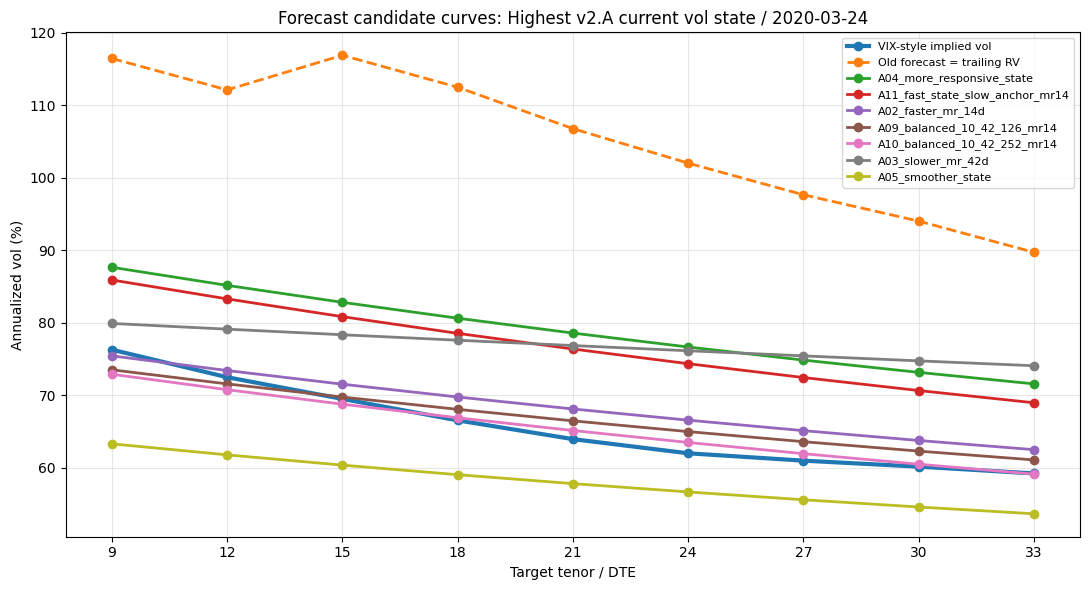

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vrp_curves_highest_v2.a_current_vol_state_20200324.png


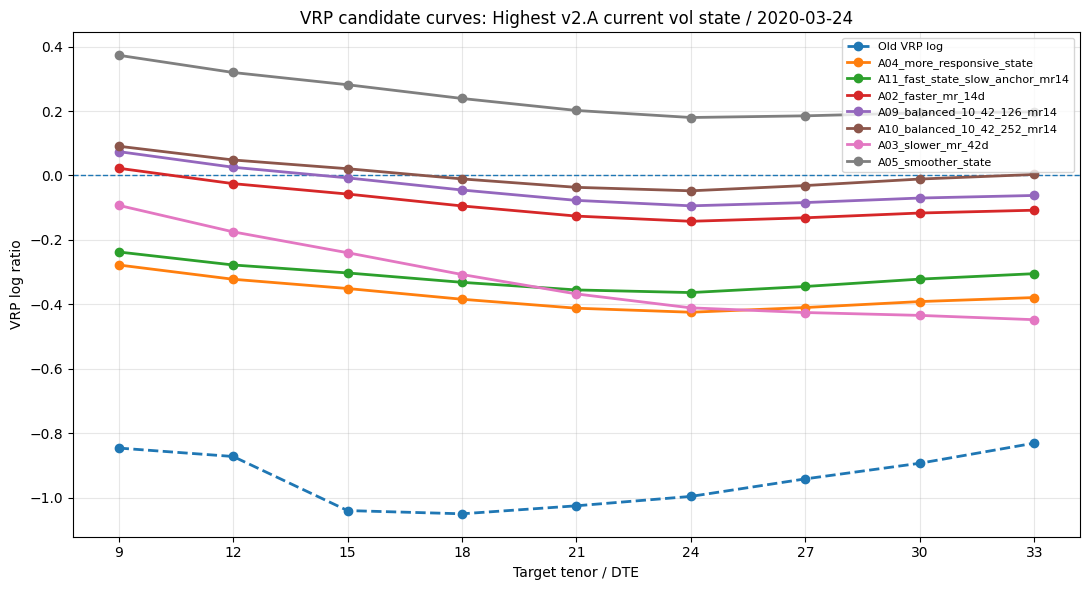

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vol_spread_highest_v2.a_current_vol_state_20200324.png


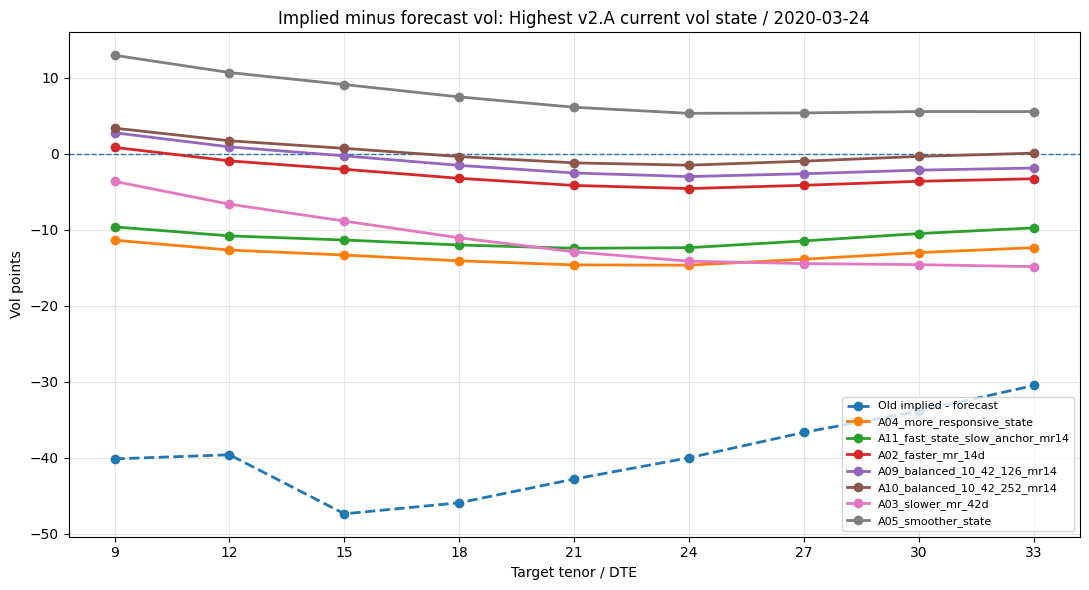


Lowest v2.A current vol state: 2018-10-03
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_forecast_curves_lowest_v2.a_current_vol_state_20181003.png


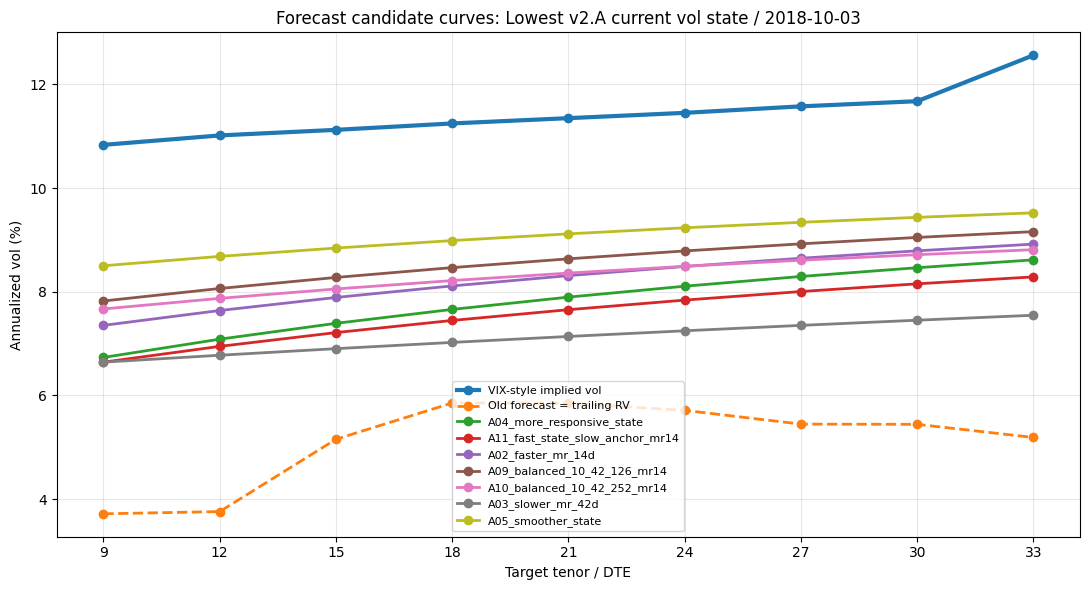

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vrp_curves_lowest_v2.a_current_vol_state_20181003.png


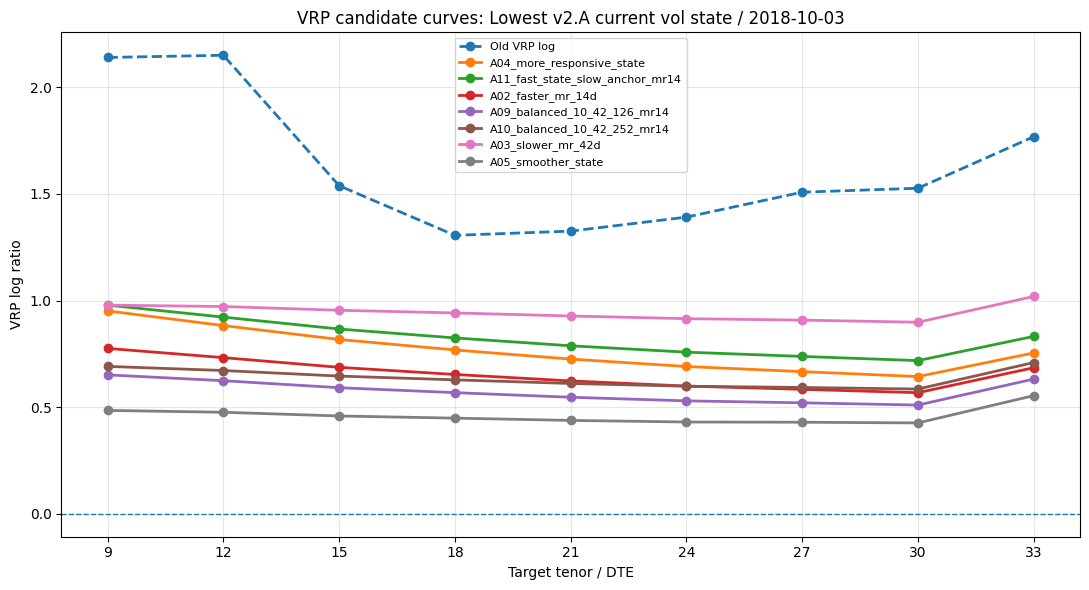

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vol_spread_lowest_v2.a_current_vol_state_20181003.png


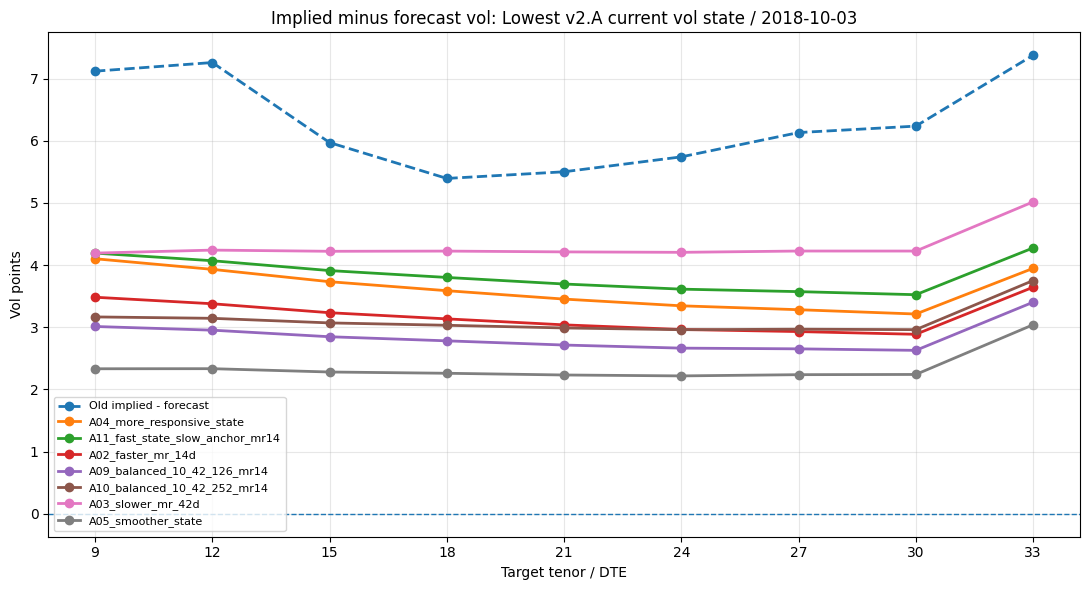


Largest SPX down-return date: 2020-03-16
Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_forecast_curves_largest_spx_down-return_date_20200316.png


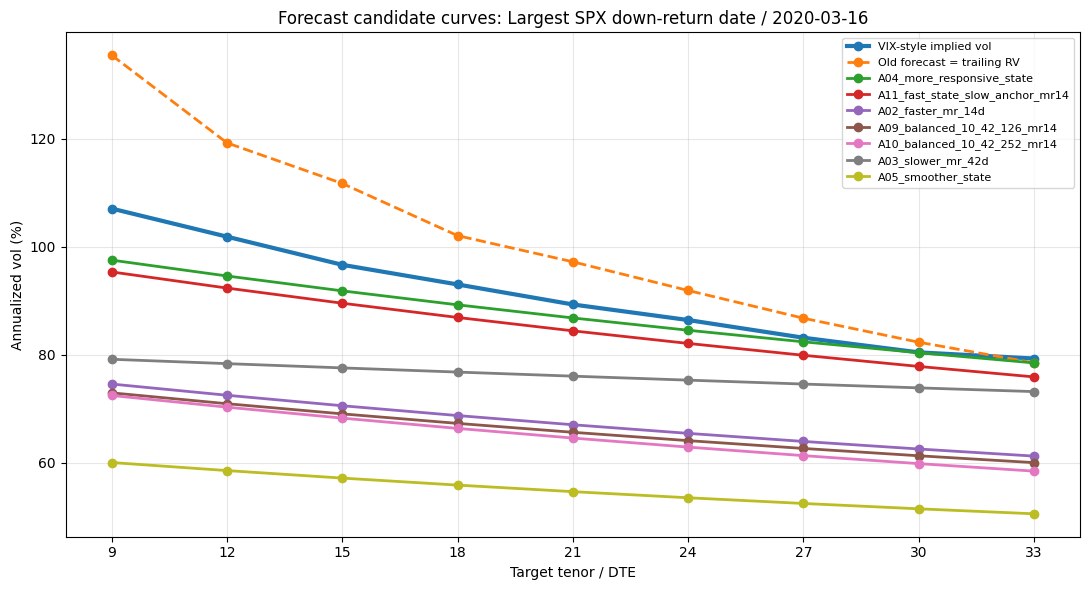

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vrp_curves_largest_spx_down-return_date_20200316.png


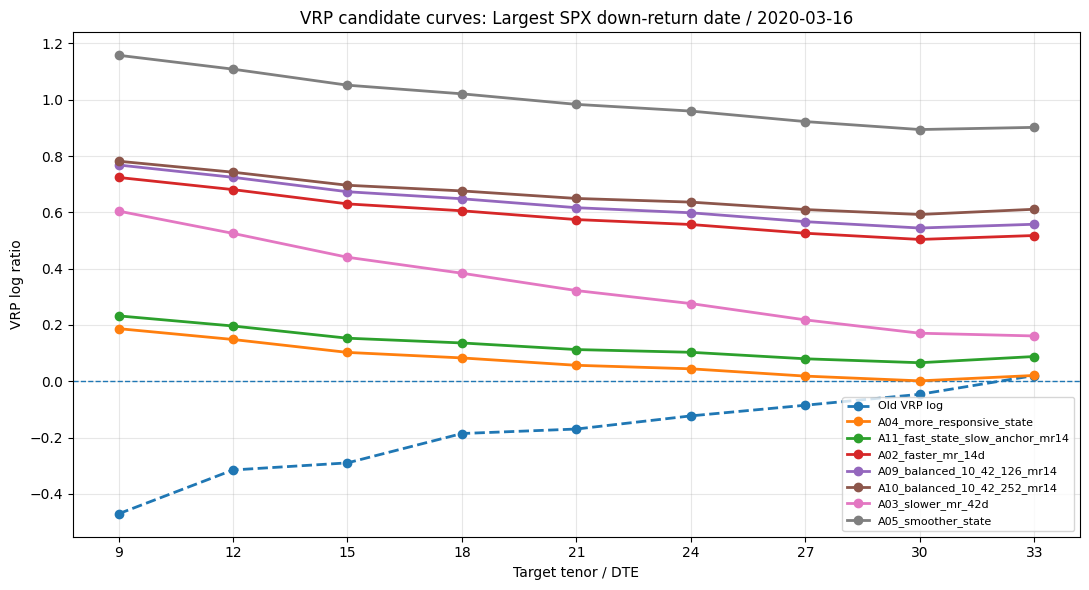

Saved: C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts\forecast_v2_cell7_candidate_vol_spread_largest_spx_down-return_date_20200316.png


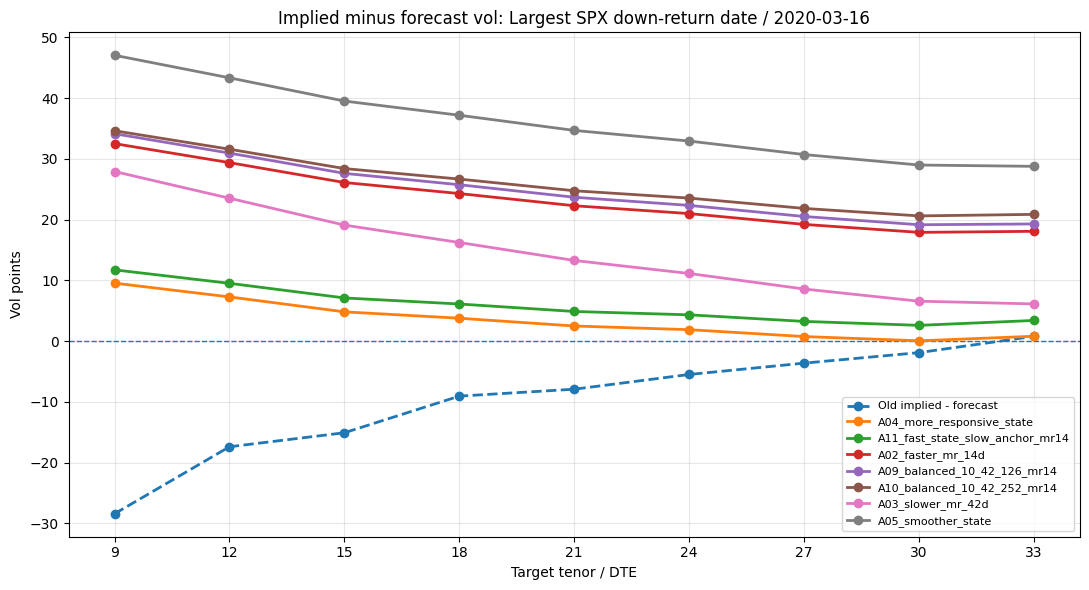


Candidate curve review by date:


,label,date,candidate_id,forecast_9d,forecast_33d,forecast_slope_9d_33d,implied_9d,implied_33d,implied_slope_9d_33d,spread_9d,spread_33d
0,Latest date,2026-07-02,OLD_trailing_realized_by_tenor,9.107617,16.298123,7.190505,12.407236,16.298491,3.891255,3.299618,0.000369
1,Latest date,2026-07-02,A04_more_responsive_state,13.539018,14.150449,0.611432,12.407236,16.298491,3.891255,-1.131782,2.148042
2,Latest date,2026-07-02,A11_fast_state_slow_anchor_mr14,13.793840,14.676989,0.883148,12.407236,16.298491,3.891255,-1.386604,1.621502
3,Latest date,2026-07-02,A02_faster_mr_14d,14.348201,14.629112,0.280911,12.407236,16.298491,3.891255,-1.940965,1.669380
4,Latest date,2026-07-02,A09_balanced_10_42_126_mr14,14.312964,14.608024,0.295061,12.407236,16.298491,3.891255,-1.905728,1.690467
5,Latest date,2026-07-02,A10_balanced_10_42_252_mr14,14.500938,15.087335,0.586398,12.407236,16.298491,3.891255,-2.093702,1.211156
6,Latest date,2026-07-02,A03_slower_mr_42d,14.237344,14.380515,0.143171,12.407236,16.298491,3.891255,-1.830108,1.917977
7,Latest date,2026-07-02,A05_smoother_state,14.421089,14.672799,0.251710,12.407236,16.298491,3.891255,-2.013853,1.625692
8,Known selected-trade test date,2026-03-30,OLD_trailing_realized_by_tenor,17.800484,15.137078,-2.663406,30.304077,30.246867,-0.057210,12.503592,15.109789
9,Known selected-trade test date,2026-03-30,A04_more_responsive_state,16.439207,15.972831,-0.466376,30.304077,30.246867,-0.057210,13.864870,14.274036



Working-candidate judgment table:


,candidate_id,initial_judgment,reason
0,A03_slower_mr_42d,Reject as main candidate for now,"Best forward error, but flagged too flat and v..."
1,A05_smoother_state,Reject as main candidate for now,"Top balanced score, but forward error and posi..."
2,A09_balanced_10_42_126_mr14,Visual contender,"Balanced and intuitive, smoother than old, not..."
3,A10_balanced_10_42_252_mr14,Visual contender,More upward term slope from slower anchor; use...
4,A02_faster_mr_14d,Visual contender,"Simple parameter change from base; smooth, not..."
5,A04_more_responsive_state,Strong working-candidate contender,"Forward error slightly better than old, not to..."
6,A11_fast_state_slow_anchor_mr14,Strong working-candidate contender,"Forward error slightly better than old, not to..."



Cell 7 outputs saved:
Candidate review table:       C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell7_candidate_curve_review_by_date_20260703_202255.csv
Working candidate judgment:   C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\forecast_v2_cell7_working_candidate_judgment_20260703_202255.csv
Charts folder:                C:\Users\patri\vrp_project\data\audit\forecast_model_research_v2\charts

Cell 7 complete.
Next step will be Cell 8: select one working candidate and build a clean candidate feature panel for deeper validation.


In [7]:
# Cell 7: plot top candidate forecast curves side-by-side
#
# Purpose:
# Cell 6 showed that no candidate should be selected purely by score.
# This cell visually compares the most relevant candidates across key dates.
#
# We want a curve that is:
# - smooth
# - not flat
# - responsive in stress
# - not obviously biased too high or too low
# - usable as a VRP denominator
#
# This cell is research-only. It does not change production files.

import matplotlib.pyplot as plt

# -----------------------------
# 1. Manual candidate shortlist
# -----------------------------

# Do not just use the top balanced score.
# Include:
# - A04 / A11: better forward error than old and not flagged too flat
# - A02 / A09 / A10: balanced smoother candidates
# - A03: best forward error but likely too flat
# - A05: top balanced score but likely biased high / over-smoothed

candidate_shortlist = [
    "A04_more_responsive_state",
    "A11_fast_state_slow_anchor_mr14",
    "A02_faster_mr_14d",
    "A09_balanced_10_42_126_mr14",
    "A10_balanced_10_42_252_mr14",
    "A03_slower_mr_42d",
    "A05_smoother_state",
]

candidate_shortlist = [
    c for c in candidate_shortlist
    if c in forecast_v2_sensitivity_curves["candidate_id"].unique()
]

candidate_review_cols = [
    "candidate_id",
    "description",
    "short_hl",
    "medium_hl",
    "long_hl",
    "short_weight",
    "medium_weight",
    "mr_hl_cal_days",
    "latest_forecast_vol_9d",
    "latest_forecast_vol_33d",
    "latest_slope_9d_33d",
    "last_year_mean_avg_abs_adjacent_move",
    "last_year_mean_abs_slope_9d_33d",
    "forward_abs_log_error_mean",
    "forward_signed_log_error_mean_bias",
    "too_flat_latest_flag",
    "balanced_review_score",
]

candidate_review_table = (
    forecast_v2_sensitivity_ranked
    .loc[
        forecast_v2_sensitivity_ranked["candidate_id"].isin(candidate_shortlist),
        candidate_review_cols,
    ]
    .sort_values("balanced_review_score", ascending=False)
    .copy()
)

print("Candidate shortlist for visual review:")
display(candidate_review_table)


# -----------------------------
# 2. Plot date selection
# -----------------------------

latest_date = feature["date"].max()

# Reuse representative dates from Cell 5 if available.
try:
    plot_dates_df = representative_dates_df.copy()
except NameError:
    plot_dates_df = pd.DataFrame([
        {"label": "Latest date", "date": latest_date},
        {"label": "Known selected-trade test date", "date": pd.Timestamp("2026-03-30")},
        {"label": "Largest SPX down-return date", "date": pd.Timestamp("2020-03-16")},
        {"label": "Highest v2.A current vol state", "date": pd.Timestamp("2020-03-24")},
    ])

plot_dates_df["date"] = pd.to_datetime(plot_dates_df["date"])

# Keep the plots focused.
preferred_plot_labels = [
    "Latest date",
    "Known selected-trade test date",
    "Largest SPX down-return date",
    "Highest v2.A current vol state",
    "Lowest v2.A current vol state",
]

plot_dates_df = (
    plot_dates_df
    .loc[plot_dates_df["label"].isin(preferred_plot_labels)]
    .drop_duplicates(subset=["label", "date"])
    .copy()
)

print()
print("Dates used for candidate curve plots:")
display(plot_dates_df)


# -----------------------------
# 3. Helper functions
# -----------------------------

def get_old_curve_for_date(selected_date):
    selected_date = pd.to_datetime(selected_date)

    old_curve = (
        feature
        .loc[feature["date"] == selected_date]
        .sort_values("tenor")
        .copy()
    )

    return old_curve


def get_candidate_curves_for_date(selected_date, candidate_ids):
    selected_date = pd.to_datetime(selected_date)

    candidate_curves = (
        forecast_v2_sensitivity_curves
        .loc[
            (forecast_v2_sensitivity_curves["date"] == selected_date)
            & (forecast_v2_sensitivity_curves["candidate_id"].isin(candidate_ids))
        ]
        .sort_values(["candidate_id", "tenor"])
        .copy()
    )

    return candidate_curves


def plot_candidate_forecast_curves(selected_date, date_label, candidate_ids, save=True):
    selected_date = pd.to_datetime(selected_date)

    old_curve = get_old_curve_for_date(selected_date)
    candidate_curves = get_candidate_curves_for_date(selected_date, candidate_ids)

    if old_curve.empty or candidate_curves.empty:
        print(f"Missing data for {date_label}: {selected_date.date()}")
        return None

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.plot(
        old_curve["tenor"],
        old_curve["vix_style_vol"],
        marker="o",
        linewidth=3,
        label="VIX-style implied vol",
    )

    ax.plot(
        old_curve["tenor"],
        old_curve["forecast_vol"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Old forecast = trailing RV",
    )

    for candidate_id in candidate_ids:
        curve = (
            candidate_curves
            .loc[candidate_curves["candidate_id"] == candidate_id]
            .sort_values("tenor")
        )

        if curve.empty:
            continue

        ax.plot(
            curve["tenor"],
            curve["forecast_vol_candidate"],
            marker="o",
            linewidth=2,
            label=candidate_id,
        )

    ax.set_title(f"Forecast candidate curves: {date_label} / {selected_date.date()}")
    ax.set_xlabel("Target tenor / DTE")
    ax.set_ylabel("Annualized vol (%)")
    ax.set_xticks(TARGET_TENORS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()

    if save:
        out = (
            FORECAST_V2_CHART_DIR
            / f"forecast_v2_cell7_candidate_forecast_curves_{date_label.replace(' ', '_').lower()}_{selected_date.strftime('%Y%m%d')}.png"
        )
        fig.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()

    return fig


def plot_candidate_vrp_curves(selected_date, date_label, candidate_ids, save=True):
    selected_date = pd.to_datetime(selected_date)

    old_curve = get_old_curve_for_date(selected_date)
    candidate_curves = get_candidate_curves_for_date(selected_date, candidate_ids)

    if old_curve.empty or candidate_curves.empty:
        print(f"Missing data for {date_label}: {selected_date.date()}")
        return None

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.axhline(0, linewidth=1, linestyle="--")

    ax.plot(
        old_curve["tenor"],
        old_curve["vrp_log"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Old VRP log",
    )

    for candidate_id in candidate_ids:
        curve = (
            candidate_curves
            .loc[candidate_curves["candidate_id"] == candidate_id]
            .sort_values("tenor")
            .merge(
                old_curve[["date", "trade_date", "tenor", "implied_variance"]],
                on=["date", "trade_date", "tenor"],
                how="left",
                validate="one_to_one",
            )
        )

        if curve.empty:
            continue

        curve["vrp_log_candidate"] = np.log(
            curve["implied_variance"]
            / curve["forecast_variance_candidate"]
        )

        ax.plot(
            curve["tenor"],
            curve["vrp_log_candidate"],
            marker="o",
            linewidth=2,
            label=candidate_id,
        )

    ax.set_title(f"VRP candidate curves: {date_label} / {selected_date.date()}")
    ax.set_xlabel("Target tenor / DTE")
    ax.set_ylabel("VRP log ratio")
    ax.set_xticks(TARGET_TENORS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()

    if save:
        out = (
            FORECAST_V2_CHART_DIR
            / f"forecast_v2_cell7_candidate_vrp_curves_{date_label.replace(' ', '_').lower()}_{selected_date.strftime('%Y%m%d')}.png"
        )
        fig.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()

    return fig


def plot_candidate_vol_spread_curves(selected_date, date_label, candidate_ids, save=True):
    selected_date = pd.to_datetime(selected_date)

    old_curve = get_old_curve_for_date(selected_date)
    candidate_curves = get_candidate_curves_for_date(selected_date, candidate_ids)

    if old_curve.empty or candidate_curves.empty:
        print(f"Missing data for {date_label}: {selected_date.date()}")
        return None

    fig, ax = plt.subplots(figsize=(11, 6))

    ax.axhline(0, linewidth=1, linestyle="--")

    old_curve = old_curve.copy()
    old_curve["old_implied_minus_forecast"] = (
        old_curve["vix_style_vol"] - old_curve["forecast_vol"]
    )

    ax.plot(
        old_curve["tenor"],
        old_curve["old_implied_minus_forecast"],
        marker="o",
        linewidth=2,
        linestyle="--",
        label="Old implied - forecast",
    )

    for candidate_id in candidate_ids:
        curve = (
            candidate_curves
            .loc[candidate_curves["candidate_id"] == candidate_id]
            .sort_values("tenor")
            .merge(
                old_curve[["date", "trade_date", "tenor", "vix_style_vol"]],
                on=["date", "trade_date", "tenor"],
                how="left",
                validate="one_to_one",
            )
        )

        if curve.empty:
            continue

        curve["candidate_implied_minus_forecast"] = (
            curve["vix_style_vol"] - curve["forecast_vol_candidate"]
        )

        ax.plot(
            curve["tenor"],
            curve["candidate_implied_minus_forecast"],
            marker="o",
            linewidth=2,
            label=candidate_id,
        )

    ax.set_title(f"Implied minus forecast vol: {date_label} / {selected_date.date()}")
    ax.set_xlabel("Target tenor / DTE")
    ax.set_ylabel("Vol points")
    ax.set_xticks(TARGET_TENORS)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    plt.tight_layout()

    if save:
        out = (
            FORECAST_V2_CHART_DIR
            / f"forecast_v2_cell7_candidate_vol_spread_{date_label.replace(' ', '_').lower()}_{selected_date.strftime('%Y%m%d')}.png"
        )
        fig.savefig(out, dpi=150)
        print(f"Saved: {out}")

    plt.show()

    return fig


# -----------------------------
# 4. Generate plots
# -----------------------------

for _, row in plot_dates_df.iterrows():
    label = row["label"]
    dt = row["date"]

    print()
    print("=" * 100)
    print(f"{label}: {dt.date()}")
    print("=" * 100)

    plot_candidate_forecast_curves(
        selected_date=dt,
        date_label=label,
        candidate_ids=candidate_shortlist,
        save=True,
    )

    plot_candidate_vrp_curves(
        selected_date=dt,
        date_label=label,
        candidate_ids=candidate_shortlist,
        save=True,
    )

    plot_candidate_vol_spread_curves(
        selected_date=dt,
        date_label=label,
        candidate_ids=candidate_shortlist,
        save=True,
    )


# -----------------------------
# 5. Build compact review table by date and candidate
# -----------------------------

review_rows = []

for _, row in plot_dates_df.iterrows():
    label = row["label"]
    dt = pd.to_datetime(row["date"])

    old_curve = get_old_curve_for_date(dt)
    candidate_curves = get_candidate_curves_for_date(dt, candidate_shortlist)

    if old_curve.empty or candidate_curves.empty:
        continue

    implied_9d = old_curve.loc[old_curve["tenor"] == 9, "vix_style_vol"].iloc[0]
    implied_33d = old_curve.loc[old_curve["tenor"] == 33, "vix_style_vol"].iloc[0]
    old_9d = old_curve.loc[old_curve["tenor"] == 9, "forecast_vol"].iloc[0]
    old_33d = old_curve.loc[old_curve["tenor"] == 33, "forecast_vol"].iloc[0]

    review_rows.append({
        "label": label,
        "date": dt,
        "candidate_id": "OLD_trailing_realized_by_tenor",
        "forecast_9d": old_9d,
        "forecast_33d": old_33d,
        "forecast_slope_9d_33d": old_33d - old_9d,
        "implied_9d": implied_9d,
        "implied_33d": implied_33d,
        "implied_slope_9d_33d": implied_33d - implied_9d,
        "spread_9d": implied_9d - old_9d,
        "spread_33d": implied_33d - old_33d,
    })

    for candidate_id in candidate_shortlist:
        curve = (
            candidate_curves
            .loc[candidate_curves["candidate_id"] == candidate_id]
            .sort_values("tenor")
        )

        if curve.empty:
            continue

        f9 = curve.loc[curve["tenor"] == 9, "forecast_vol_candidate"].iloc[0]
        f33 = curve.loc[curve["tenor"] == 33, "forecast_vol_candidate"].iloc[0]

        review_rows.append({
            "label": label,
            "date": dt,
            "candidate_id": candidate_id,
            "forecast_9d": f9,
            "forecast_33d": f33,
            "forecast_slope_9d_33d": f33 - f9,
            "implied_9d": implied_9d,
            "implied_33d": implied_33d,
            "implied_slope_9d_33d": implied_33d - implied_9d,
            "spread_9d": implied_9d - f9,
            "spread_33d": implied_33d - f33,
        })

candidate_curve_review_by_date = pd.DataFrame(review_rows)

print()
print("Candidate curve review by date:")
display(candidate_curve_review_by_date)


# -----------------------------
# 6. Working-candidate judgment table
# -----------------------------

working_judgment_rows = [
    {
        "candidate_id": "A03_slower_mr_42d",
        "initial_judgment": "Reject as main candidate for now",
        "reason": "Best forward error, but flagged too flat and visually likely under-expressive across tenor.",
    },
    {
        "candidate_id": "A05_smoother_state",
        "initial_judgment": "Reject as main candidate for now",
        "reason": "Top balanced score, but forward error and positive bias are materially worse than old.",
    },
    {
        "candidate_id": "A09_balanced_10_42_126_mr14",
        "initial_judgment": "Visual contender",
        "reason": "Balanced and intuitive, smoother than old, not too flat, but forward error is worse than old.",
    },
    {
        "candidate_id": "A10_balanced_10_42_252_mr14",
        "initial_judgment": "Visual contender",
        "reason": "More upward term slope from slower anchor; useful if we want a higher long-end forecast.",
    },
    {
        "candidate_id": "A02_faster_mr_14d",
        "initial_judgment": "Visual contender",
        "reason": "Simple parameter change from base; smooth, not too flat, but forward error is worse than old.",
    },
    {
        "candidate_id": "A04_more_responsive_state",
        "initial_judgment": "Strong working-candidate contender",
        "reason": "Forward error slightly better than old, not too flat, and more responsive to recent volatility.",
    },
    {
        "candidate_id": "A11_fast_state_slow_anchor_mr14",
        "initial_judgment": "Strong working-candidate contender",
        "reason": "Forward error slightly better than old, not too flat, responsive current state, slower long anchor.",
    },
]

working_candidate_judgment_df = pd.DataFrame(working_judgment_rows)

print()
print("Working-candidate judgment table:")
display(working_candidate_judgment_df)


# -----------------------------
# 7. Save Cell 7 outputs
# -----------------------------

cell7_candidate_review_table_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell7_candidate_curve_review_by_date_{RUN_TIMESTAMP}.csv"
)

cell7_working_judgment_output = (
    FORECAST_V2_AUDIT_DIR
    / f"forecast_v2_cell7_working_candidate_judgment_{RUN_TIMESTAMP}.csv"
)

candidate_curve_review_by_date.to_csv(cell7_candidate_review_table_output, index=False)
working_candidate_judgment_df.to_csv(cell7_working_judgment_output, index=False)

print()
print("Cell 7 outputs saved:")
print(f"Candidate review table:       {cell7_candidate_review_table_output}")
print(f"Working candidate judgment:   {cell7_working_judgment_output}")
print(f"Charts folder:                {FORECAST_V2_CHART_DIR}")

print()
print("Cell 7 complete.")
print("Next step will be Cell 8: select one working candidate and build a clean candidate feature panel for deeper validation.")